In [2]:
# STANDARD LIBRARIES
import datetime
import itertools
import random
import warnings

# DATA MANIPULATION
import numpy as np
import pandas as pd

# VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

# SKLEARN - PREPROCESSING
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, LabelEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

# SKLEARN - MODEL SELECTION
from sklearn.model_selection import (
    train_test_split, StratifiedKFold
)

# SKLEARN - METRICS
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, precision_recall_curve
)

# SKLEARN - MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV

# IMBALANCED LEARN
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.pipeline import Pipeline

# XGBOOST
import xgboost as xgb
from xgboost import XGBClassifier

# STATSMODELS
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# HYPERPARAMETER TUNING
import optuna
from optuna.pruners import MedianPruner

# MODEL INTERPRETABILITY
import shap

# NLP / TRANSFORMERS
import torch
from transformers import AutoTokenizer, AutoModel
warnings.filterwarnings('ignore')

C:\Users\Krafc\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load dataset

df = pd.read_csv("loan.csv", low_memory=False)
print("Original shape:", df.shape)
df['desc'].replace(' ', np.nan, inplace=True)
df = df[df['desc'].notna()]
print("New shape:", df.shape)


Original shape: (2260668, 145)
New shape: (125813, 145)


In [4]:
# Get unique values of the target 
unique_target_values = df['loan_status'].dropna().unique()
unique_target_values = list(unique_target_values)
unique_target_values

['Fully Paid',
 'Current',
 'Charged Off',
 'Late (16-30 days)',
 'Late (31-120 days)',
 'In Grace Period',
 'Does not meet the credit policy. Status:Fully Paid',
 'Does not meet the credit policy. Status:Charged Off']

In [5]:
# Define mapping dictionary for safe vs risky loans
status_mapping = {
    'Fully Paid': 'Paid',
    'Does not meet the credit policy. Status:Fully Paid': 'Paid',
    'Charged Off': 'Defaulted',
    'Default': 'Defaulted',
    'Does not meet the credit policy. Status:Charged Off': 'Defaulted'
}

# Apply mapping to create a new column
df['loan_risk'] = df['loan_status'].map(status_mapping)

# Check results
print(df[['loan_status', 'loan_risk']].drop_duplicates())


                                               loan_status  loan_risk
549891                                          Fully Paid       Paid
574301                                             Current        NaN
644960                                         Charged Off  Defaulted
1675803                                  Late (16-30 days)        NaN
1683496                                 Late (31-120 days)        NaN
2056190                                    In Grace Period        NaN
2139273  Does not meet the credit policy. Status:Fully ...       Paid
2139288  Does not meet the credit policy. Status:Charge...  Defaulted


**From here the target will be 'loan_risk' to align with our objective**

In [6]:
#Keep only application-time variables
#Feature Engineering Financial Indicators
#used to construct financial ratios that may better capture borrower risk than raw variables alone.

df["interest_burden"] = df["installment"] / (df["annual_inc"]/12 + 1) # Monthly payment burden
df["loansize_per_income"] = df["loan_amnt"] / (df["annual_inc"] + 1) # Total loan burden

# Credit history prior to loan application/approval
df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], errors="coerce") # converting columns to datetime
df["issue_d"] = pd.to_datetime(df["issue_d"], errors="coerce")

# Calculating credit history in months
df["credit_history_months"] = (df["issue_d"] - df["earliest_cr_line"]).dt.days // 30

candidate_features = ["loansize_per_income","interest_burden", "credit_history_months",
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "dti",
    "delinq_2yrs",
    "fico_range_low",
    "fico_range_high",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "initial_list_status",
    "application_type",
    "desc"
]

available_features = [col for col in candidate_features if col in df.columns]
baseline_df = df[available_features + ["loan_risk"]].copy()

print("\nSelected columns:")
print(baseline_df.columns.tolist())
print("Shape after feature selection:", baseline_df.shape)


Selected columns:
['loansize_per_income', 'interest_burden', 'credit_history_months', 'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'application_type', 'desc', 'loan_risk']
Shape after feature selection: (125813, 26)


**the df used from here on out should be baseline_df**

In [7]:
# Creating a copy so that baseline_df is its own dataset instead of being dependent on df
baseline_df = baseline_df.copy()

In [8]:
# 6. Dropping columns with too many missing values
missing_ratio = baseline_df.isnull().mean()
high_missing_cols = missing_ratio[missing_ratio > 0.50].index.tolist()
high_missing_cols = [col for col in high_missing_cols if col != "loan_risk"]

baseline_df.drop(columns=high_missing_cols, inplace=True)

print("\nDropped columns with >50% missing values:")
print(high_missing_cols)
print("Shape after dropping high-missing columns:", baseline_df.shape)



Dropped columns with >50% missing values:
[]
Shape after dropping high-missing columns: (125813, 26)


In [9]:
# Clean emp_length
if "emp_length" in baseline_df.columns:
    baseline_df["emp_length"] = baseline_df["emp_length"].astype("string")
    baseline_df["emp_length"] = baseline_df["emp_length"].replace("n/a", pd.NA)

    baseline_df["emp_length"] = (
        baseline_df["emp_length"]
        .str.replace(r"\+ years", "", regex=True)
        .str.replace(r" years", "", regex=True)
        .str.replace(r" year", "", regex=True)
        .str.replace(r"< 1", "0", regex=True)
    )

    baseline_df["emp_length"] = pd.to_numeric(baseline_df["emp_length"], errors="coerce")
    
# Clean term
if "term" in baseline_df.columns:
    baseline_df["term"] = baseline_df["term"].astype("string").str.extract(r"(\d+)")[0]
    baseline_df["term"] = pd.to_numeric(baseline_df["term"], errors="coerce")

# Clean int_rate
if "int_rate" in baseline_df.columns:
    baseline_df["int_rate"] = baseline_df["int_rate"].astype("string").str.replace("%", "", regex=False)
    baseline_df["int_rate"] = pd.to_numeric(baseline_df["int_rate"], errors="coerce")

# Clean revol_util
if "revol_util" in baseline_df.columns:
    baseline_df["revol_util"] = baseline_df["revol_util"].astype("string").str.replace("%", "", regex=False)
    baseline_df["revol_util"] = pd.to_numeric(baseline_df["revol_util"], errors="coerce")

In [10]:
# Displaying string-free features from the process above
baseline_df[["emp_length", "term", "int_rate", "revol_util"]].head()

,emp_length,term,int_rate,revol_util
549891,0,36,24.99,74.0
574301,10,60,15.59,21.2
584703,10,36,7.99,42.4
588313,10,60,12.79,28.0
597503,10,36,9.75,71.9


#### Baseline dataset to only include paid or defaulted as target variable

In [11]:
# This code removes NaN in loan risk column which corresponds to 'Current', 'Late' and 'In Grace Period'
# We're only focusing on Paid, or defaulted (which includes charged off loans)
baseline_df = baseline_df[(baseline_df['loan_risk'] == 'Paid')| (baseline_df['loan_risk'] == 'Defaulted')]
baseline_df.shape

(125498, 26)

#### Datatypes

In [12]:
baseline_df.dtypes

loansize_per_income      float64
interest_burden          float64
credit_history_months    float64
loan_amnt                  int64
term                       Int64
int_rate                 Float64
installment              float64
grade                     object
sub_grade                 object
emp_length                 Int64
home_ownership            object
annual_inc               float64
verification_status       object
purpose                   object
dti                      float64
delinq_2yrs              float64
inq_last_6mths           float64
open_acc                 float64
pub_rec                  float64
revol_bal                  int64
revol_util               Float64
total_acc                float64
initial_list_status       object
application_type          object
desc                      object
loan_risk                 object
dtype: object

In [13]:
# Fixing data types

baseline_df["home_ownership"] = baseline_df["home_ownership"].astype("category") # object to category
baseline_df["purpose"] = baseline_df["purpose"].astype("category") # object to category
baseline_df["application_type"] = baseline_df["application_type"].astype("category") # object to category
baseline_df["loan_risk"] = baseline_df["loan_risk"].astype("category") # object to category

In [14]:
# Second check on datatypes to ensure accuracy
baseline_df.dtypes

loansize_per_income       float64
interest_burden           float64
credit_history_months     float64
loan_amnt                   int64
term                        Int64
int_rate                  Float64
installment               float64
grade                      object
sub_grade                  object
emp_length                  Int64
home_ownership           category
annual_inc                float64
verification_status        object
purpose                  category
dti                       float64
delinq_2yrs               float64
inq_last_6mths            float64
open_acc                  float64
pub_rec                   float64
revol_bal                   int64
revol_util                Float64
total_acc                 float64
initial_list_status        object
application_type         category
desc                       object
loan_risk                category
dtype: object

#### Missing Values

In [15]:
baseline_df.isnull().sum()

loansize_per_income         4
interest_burden             4
credit_history_months      28
loan_amnt                   0
term                        0
int_rate                    0
installment                 0
grade                       0
sub_grade                   0
emp_length               5068
home_ownership              0
annual_inc                  4
verification_status         0
purpose                     0
dti                         0
delinq_2yrs                28
inq_last_6mths             28
open_acc                   28
pub_rec                    28
revol_bal                   0
revol_util                127
total_acc                  28
initial_list_status         0
application_type            0
desc                        0
loan_risk                   0
dtype: int64

#### Examining Distribution of features with missing values to help determine imputation method

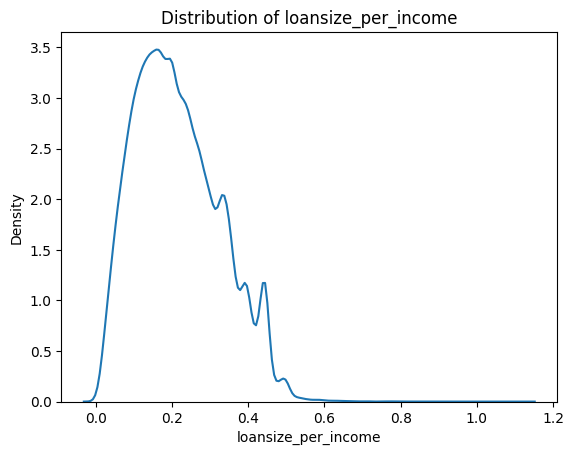

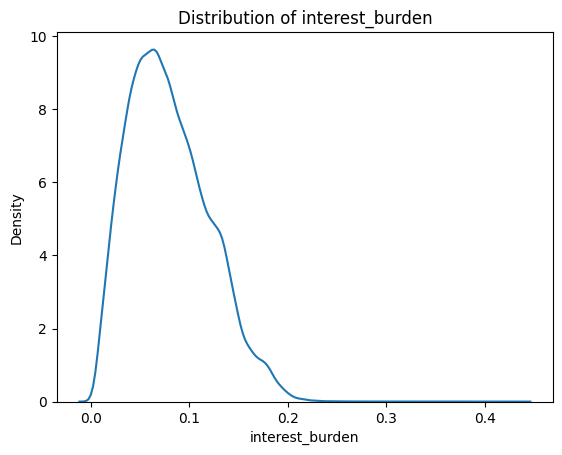

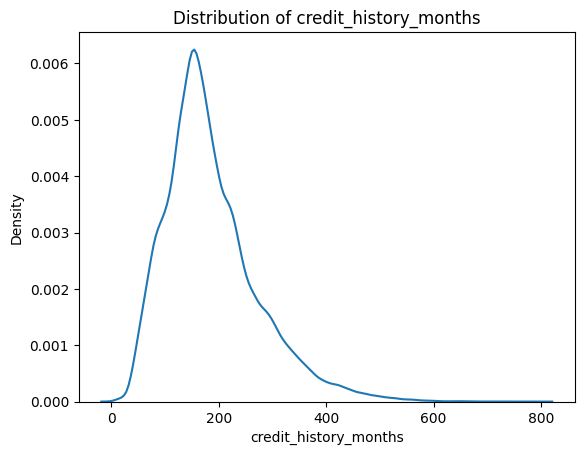

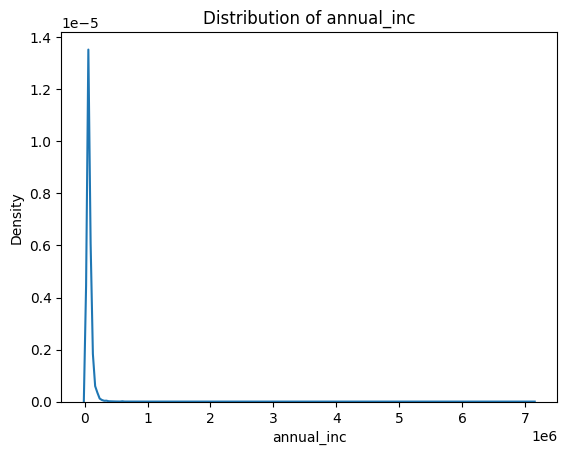

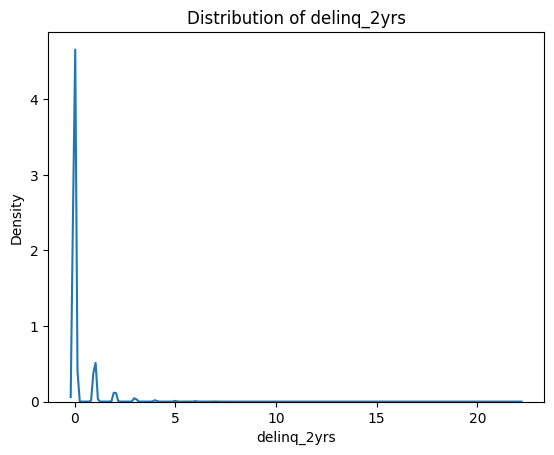

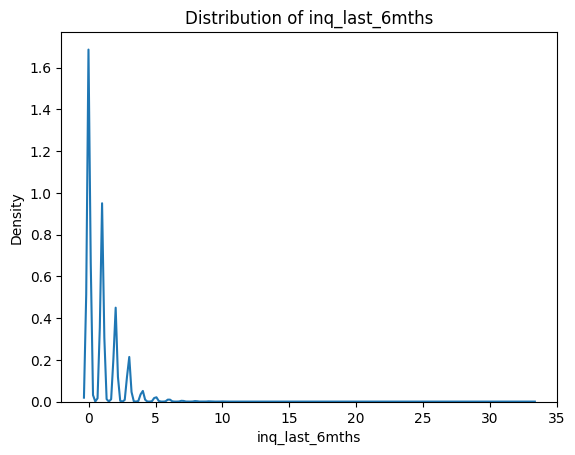

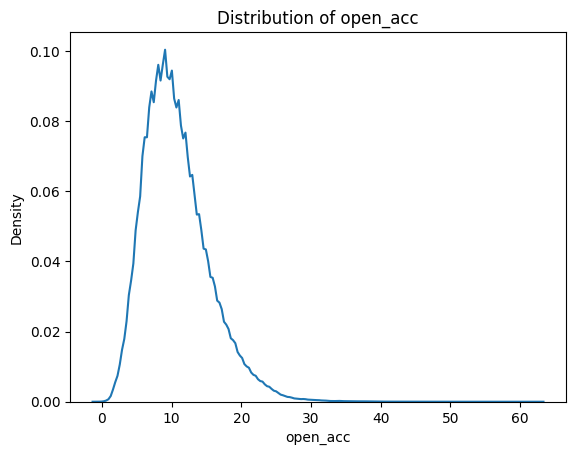

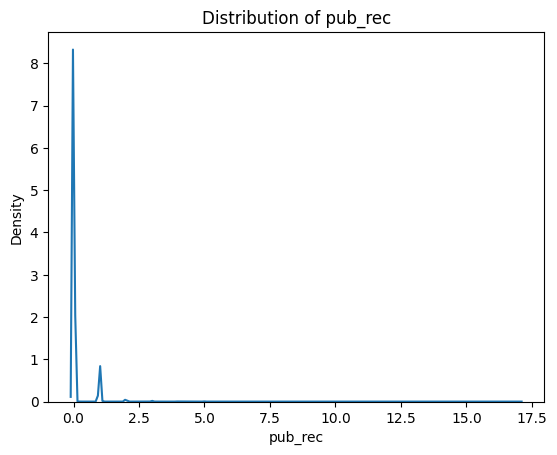

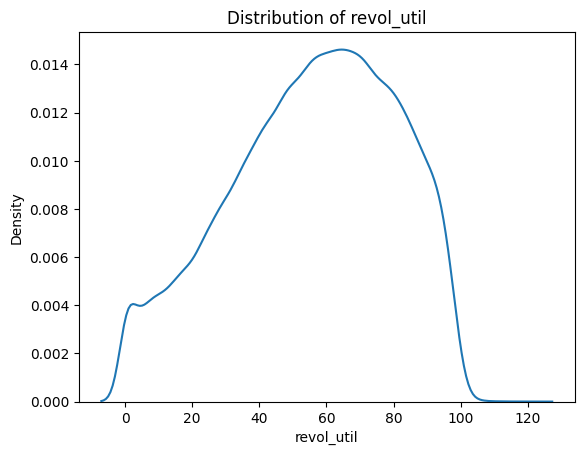

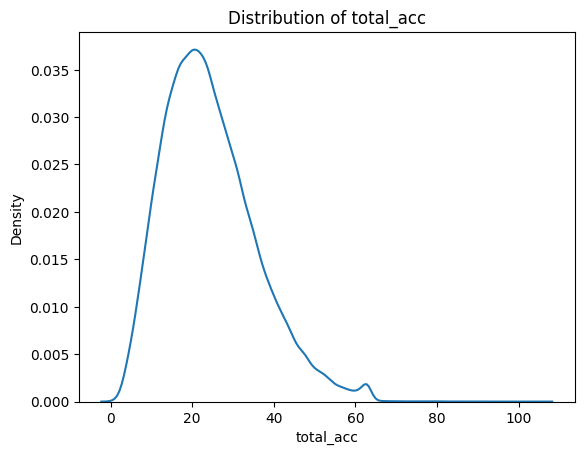

In [16]:
# Columns with missing values
missing_cols = baseline_df.columns[baseline_df.isnull().any()]

# Keeping only continuous columns (excluding categorical and integer)
kde_cols = baseline_df[missing_cols].select_dtypes(include=["Float64","float64", "float32"]).columns

# plotting distribution for each column with missing values
for col in kde_cols:
    plt.figure()
    sns.kdeplot(baseline_df[col].dropna())
    plt.title(f"Distribution of {col}")
    plt.show()

#### Handling Missing Values
Since the distribution of all the continuous features are skewed, median and the number of missing values per is very low, median imputation would be the best approach

In [17]:
# No need to impute categorical columns since there's none with missing values in the baseline dataset

# Fetching the numerical columns with missing values
numeric_cols_with_na = [
    col for col in baseline_df.columns
    if baseline_df[col].dtype in ["float64", "float32", "int64", "Int64","Float64"]
    and baseline_df[col].isnull().any()
]
    # For those numerical columns, impute missing values with median
for col in numeric_cols_with_na:
    baseline_df[col] = baseline_df[col].fillna(baseline_df[col].median())

In [18]:
# Checking to ensure all missing values have been handled
baseline_df.isnull().sum()

loansize_per_income      0
interest_burden          0
credit_history_months    0
loan_amnt                0
term                     0
int_rate                 0
installment              0
grade                    0
sub_grade                0
emp_length               0
home_ownership           0
annual_inc               0
verification_status      0
purpose                  0
dti                      0
delinq_2yrs              0
inq_last_6mths           0
open_acc                 0
pub_rec                  0
revol_bal                0
revol_util               0
total_acc                0
initial_list_status      0
application_type         0
desc                     0
loan_risk                0
dtype: int64

In [19]:
# 11. Saving the baseline dataset 
baseline_bert_df = baseline_df.copy()
baseline_bert_df.to_csv("baseline_bert_dataset.csv", index=False)
# Drop 'desc' column from baseline_df
baseline_df = baseline_df.drop(columns=['desc'])
# Saving the baseline dataset for next sections
baseline_df.to_csv("baseline_dataset.csv", index=False)

In [20]:
# Section 2

In [21]:
#Load dataset

In [22]:
df1 = pd.read_csv("baseline_dataset.csv")

In [23]:
df1.head()

,loansize_per_income,interest_burden,credit_history_months,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,...,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,loan_risk
0,0.113692,0.054221,162.0,3500,36,24.99,139.15,E,E4,0,...,0.0,4.0,14.0,1.0,7849,74.0,36.0,w,Individual,Paid
1,0.046666,0.017544,237.0,4200,36,7.99,131.60,A,A4,10,...,0.0,0.0,12.0,0.0,9533,42.4,25.0,w,Individual,Paid
2,0.189472,0.073090,143.0,18000,36,9.75,578.70,B,B3,10,...,0.0,0.0,8.0,0.0,22075,71.9,14.0,w,Individual,Paid
3,0.116787,0.046191,166.0,16000,36,11.47,527.39,B,B5,4,...,0.0,2.0,31.0,0.0,38885,59.5,62.0,w,Individual,Paid
4,0.135383,0.059533,166.0,8800,36,18.99,322.53,D,D4,2,...,0.0,1.0,19.0,0.0,14741,81.9,26.0,w,Individual,Defaulted


#### Train / Validation / Test Split

In [24]:

X = df1.drop("loan_risk", axis=1)
y = df1["loan_risk"]

# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

In [25]:
print(len(X_train)/len(X))
print(len(X_val)/len(X))
print(len(X_test)/len(X))

0.6999952190473155
0.15000239047634226
0.15000239047634226


In [26]:
# Identify numerical columns

In [27]:
num_cols = X_train.select_dtypes(include=["int64", "float64", "float32", "Int64"]).columns
print("Numerical columns:")
print(num_cols)

Numerical columns:
Index(['loansize_per_income', 'interest_burden', 'credit_history_months',
       'loan_amnt', 'term', 'int_rate', 'installment', 'emp_length',
       'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc'],
      dtype='object')


#### Outlier check (TRAIN DATASET ONLY)

In [28]:
def count_outliers_iqr(train_data, column_name):
    Q1 = train_data[column_name].quantile(0.25)
    Q3 = train_data[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = ((train_data[column_name] < lower_bound) | 
                     (train_data[column_name] > upper_bound)).sum()
    return outlier_count

print("Outlier count in training data:")
for col in num_cols:
    print(f"{col}: {count_outliers_iqr(X_train, col)}")

Outlier count in training data:
loansize_per_income: 189
interest_burden: 373
credit_history_months: 2779
loan_amnt: 0
term: 19975
int_rate: 326
installment: 2047
emp_length: 0
annual_inc: 3624
dti: 1
delinq_2yrs: 12857
inq_last_6mths: 8424
open_acc: 1688
pub_rec: 8035
revol_bal: 4202
revol_util: 0
total_acc: 1504


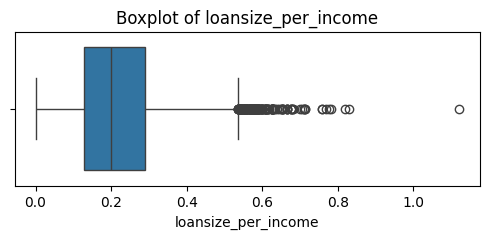

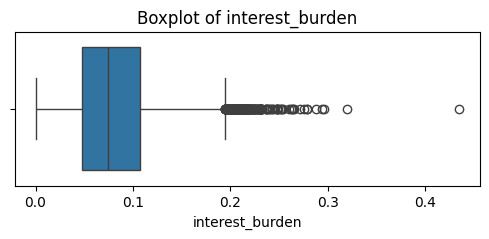

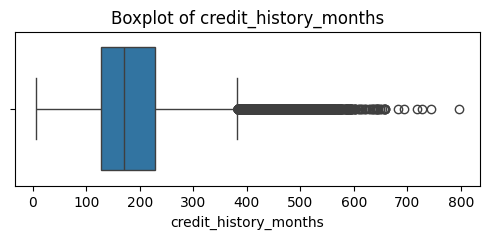

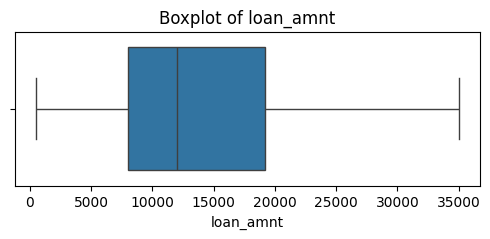

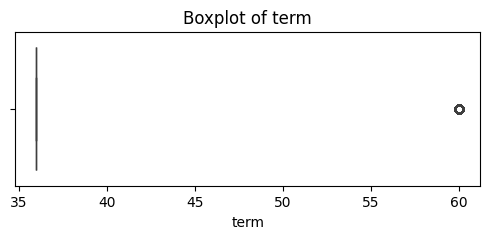

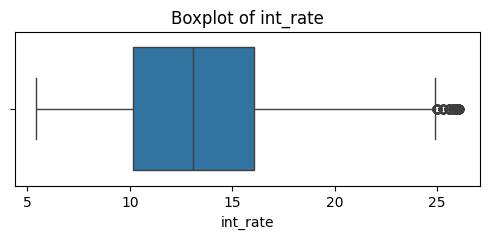

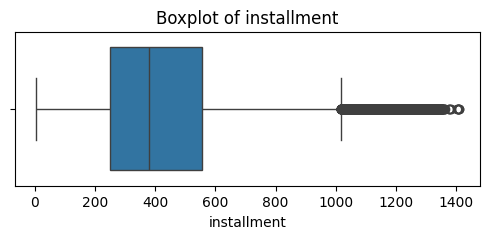

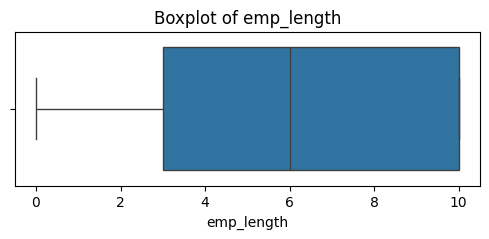

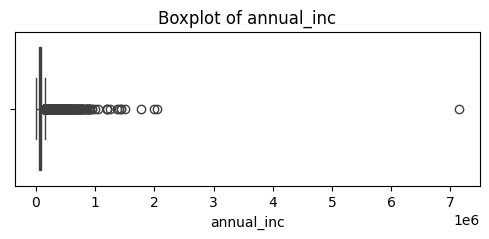

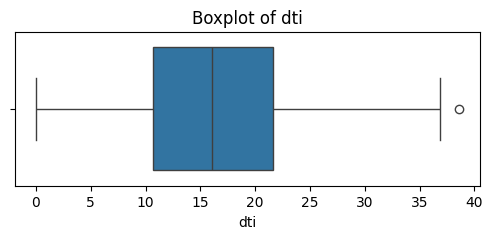

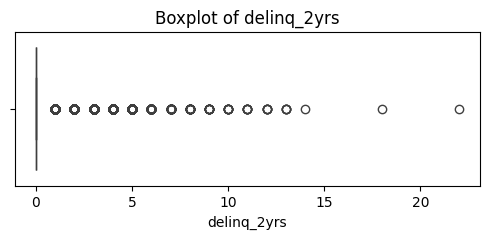

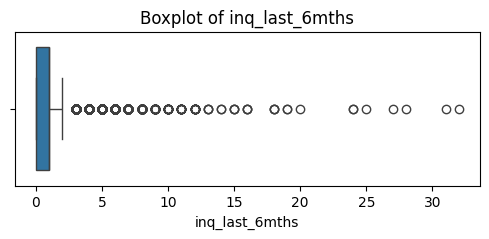

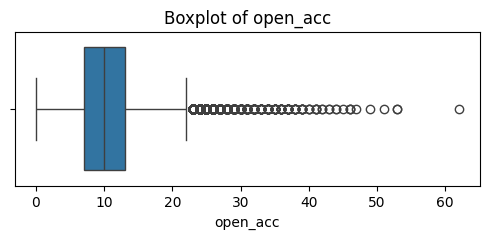

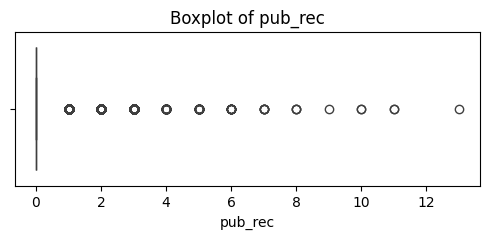

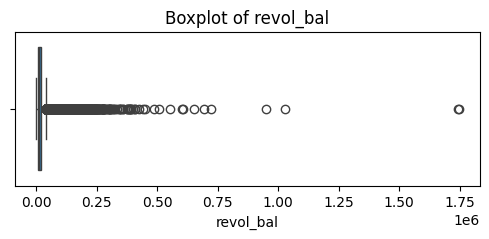

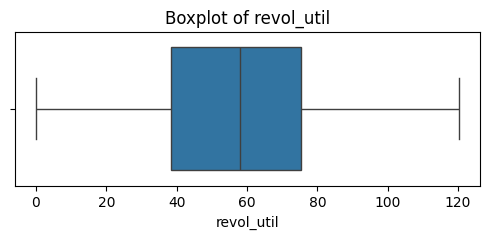

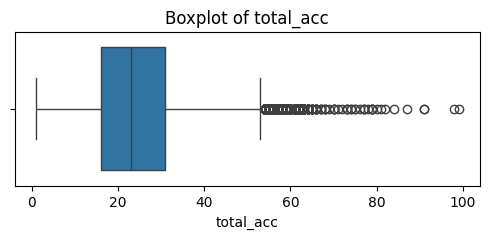

In [29]:
# Boxplots for visual checking
for col in num_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=X_train[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [30]:
# Making safe copies before modifying
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

# Log transform selected skewed columns
log_cols = [
    "annual_inc",
    "loan_amnt",
    "revol_bal",
    "installment",
    "loansize_per_income",
    "interest_burden"
]

for col in log_cols:
    if col in X_train.columns:
        X_train[col] = np.log1p(X_train[col])
        X_val[col] = np.log1p(X_val[col])
        X_test[col] = np.log1p(X_test[col])

### DATA  BEFORE SCALING

In [31]:
X_train.to_csv("X_train_before_scaling.csv", index=False)
X_val.to_csv("X_val_before_scaling.csv", index=False)
X_test.to_csv("X_test_before_scaling.csv", index=False)

# SCALING

In [32]:
# Scale only original numerical columns
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

### DATA AFTER SCALING

In [33]:
X_train.to_csv("X_train_after_scaling.csv", index=False)
X_val.to_csv("X_val_after_scaling.csv", index=False)
X_test.to_csv("X_test_after_scaling.csv", index=False)

### TARGET

In [34]:
# CONVERT TARGET TO NUMERIC (0/1)
y_train = y_train.map({'Paid': 0, 'Defaulted': 1})
y_val = y_val.map({'Paid': 0, 'Defaulted': 1})
y_test = y_test.map({'Paid': 0, 'Defaulted': 1})

In [35]:
# SAVE
y_train.to_csv("y_train.csv", index=False)
y_val.to_csv("y_val.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

In [36]:
print('done')

done


### Section 2

#### Encoding Categorical Columns

In [37]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols

['grade',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'purpose',
 'initial_list_status',
 'application_type']

#### Ordinal Encoding for grade and sub_grade features

In [38]:
# defining the ordinal order of credit grades based on risk hierarchy (A = best, G = worst)
grade_order = ['A','B','C','D','E','F','G']

# creating the full ordered list of subgrades (A1 → A5, B1 → B5, ..., G1 → G5)
subgrade_order = [f"{g}{i}" for g in grade_order for i in range(1,6)]

# creating mapping dictionaries to convert categorical grades into ordinal integers
grade_mapping = {g: i for i, g in enumerate(grade_order)}
subgrade_mapping = {sg: i for i, sg in enumerate(subgrade_order)}

# applying ordinal encoding to the 'grade' column across training, validation, and test sets
X_train['grade'] = X_train['grade'].map(grade_mapping)
X_val['grade']   = X_val['grade'].map(grade_mapping)
X_test['grade']  = X_test['grade'].map(grade_mapping)

# applying ordinal encoding to the 'sub_grade' column across training, validation, and test sets
X_train['sub_grade'] = X_train['sub_grade'].map(subgrade_mapping)
X_val['sub_grade']   = X_val['sub_grade'].map(subgrade_mapping)
X_test['sub_grade']  = X_test['sub_grade'].map(subgrade_mapping)

In [39]:
# Check for grade encoding success
X_train['grade'].unique()

array([1, 3, 0, 2, 4, 5, 6], dtype=int64)

In [40]:
# check for sub_grade encoding success
X_train['sub_grade'].unique()

array([ 5, 19,  0, 12,  7,  6, 11, 23, 10,  9, 14, 25,  1, 15,  8,  4,  2,
        3, 17, 20, 22, 18, 13, 16, 28, 26, 24, 33, 21, 30, 27, 29, 31, 32,
       34], dtype=int64)

#### One-Hot Encoding for the remaining categorical variables

In [41]:

# defining nominal categorical columns for one-hot encoding
nominal_cols = [
    'home_ownership',
    'verification_status',
    'purpose',
    'initial_list_status',
    'application_type'
]

# initializing one-hot encoder while dropping the first category and handling unseen categories safely
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# fitting the encoder on training data and transforming training features
X_train_ohe = ohe.fit_transform(X_train[nominal_cols])

# transforming validation data using the training-fitted encoder
X_val_ohe = ohe.transform(X_val[nominal_cols])

# transforming test data using the training-fitted encoder
X_test_ohe = ohe.transform(X_test[nominal_cols])

# creating dataframes with consistent feature names
ohe_cols = ohe.get_feature_names_out(nominal_cols)
X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_cols, index=X_train.index)
X_val_ohe   = pd.DataFrame(X_val_ohe, columns=ohe_cols, index=X_val.index)
X_test_ohe  = pd.DataFrame(X_test_ohe, columns=ohe_cols, index=X_test.index)

# dropping original nominal columns from each dataset
X_train = X_train.drop(columns=nominal_cols)
X_val   = X_val.drop(columns=nominal_cols)
X_test  = X_test.drop(columns=nominal_cols)

# concatenating one-hot encoded features back into each dataset
X_train = pd.concat([X_train, X_train_ohe], axis=1)
X_val   = pd.concat([X_val, X_val_ohe], axis=1)
X_test  = pd.concat([X_test, X_test_ohe], axis=1)

In [42]:
# checking newly created one-hot encoded column names
print([col for col in X_train.columns if any(n in col for n in nominal_cols)])

['home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding', 'initial_list_status_w']


### Multicollinearity Check

### Heatmap

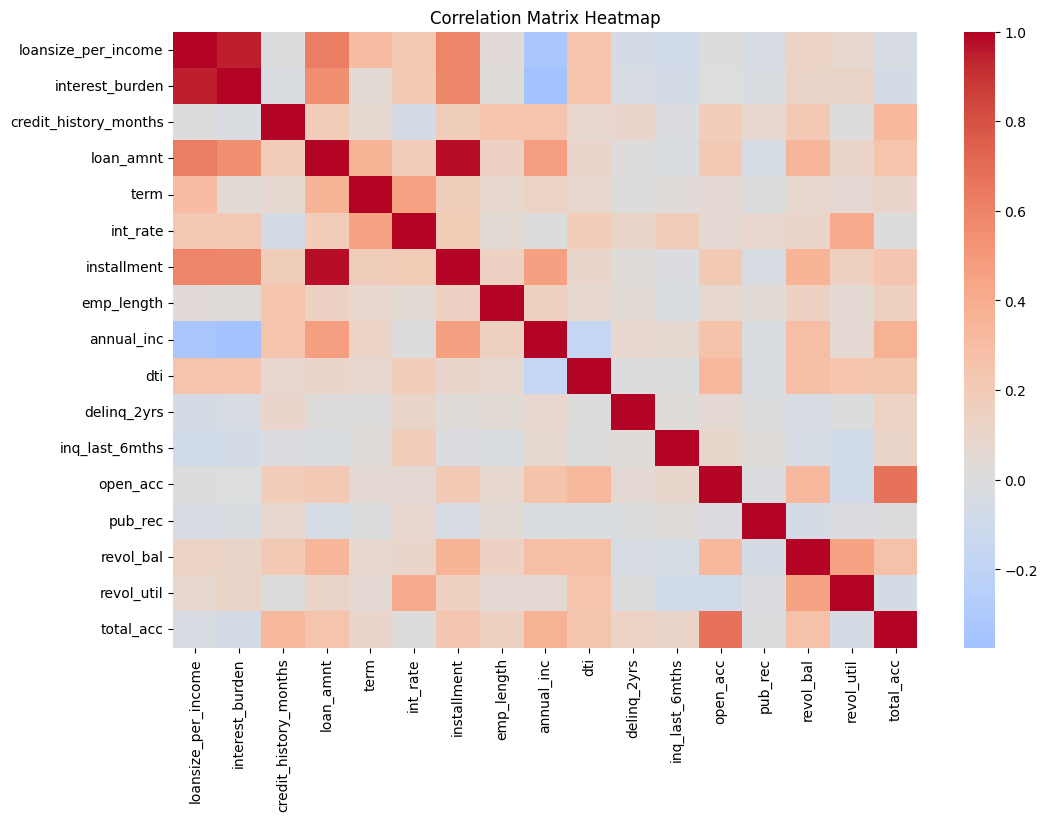

In [43]:
# selecting only numerical features, computing correlation matrix, and plotting heatmap

corr_matrix = X_train[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)

plt.title("Correlation Matrix Heatmap")
plt.show()

#### Correlation pairs >= 0.70

In [44]:
# creating correlation matrix from numerical features
corr_matrix = X_train[num_cols].corr()

# unstacking correlation matrix into pairs
corr_pairs = corr_matrix.unstack()

# removing self-correlations (correlation of a variable with itself)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# removing duplicate pairs (keeping one of each pair)
corr_pairs = corr_pairs.sort_index()
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()]

# filtering for strong correlations (>= 0.70 or <= -0.70)
strong_corr = corr_pairs[abs(corr_pairs) >= 0.70]

# sorting correlations in descending order
strong_corr = strong_corr.sort_values(ascending=False)

# converting to dataframe for readability
strong_corr_df = strong_corr.reset_index()
strong_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

print(strong_corr_df)

             Feature_1            Feature_2  Correlation
0          installment            loan_amnt     0.973316
1            loan_amnt          installment     0.973316
2      interest_burden  loansize_per_income     0.946324
3  loansize_per_income      interest_burden     0.946324


Installment is almost perfectly correlated with loan_amnt. It's logical to think that installment is largely dependent on loan_amnt issued. Hence it would be reasonable to drop installment and keep loan_amnt.

In a similar manner,interest_burden and loansize_per_income are nearly perfectly correlated. Both variables capture nearly the same underlying relationship between loan size and borrower capacity. This introduces redundancy. Loansize_per_income is more intuitive, hence removing interest_burden.

Keeping both open_acc and total_acc for now (they're not as extreme as the preceding two pairs) and will decide later how to handle the pair after VIF

#### Dropping installment and interest_burden features

In [45]:
# dropping highly collinear and redundant features
X_train = X_train.drop(columns=['installment', 'interest_burden'])
X_val   = X_val.drop(columns=['installment', 'interest_burden'])
X_test  = X_test.drop(columns=['installment', 'interest_burden'])

In [46]:
# calculating VIF to assess multicollinearity

# creating a copy of training data
X_vif = X_train.copy()

# computing VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# sorting VIF values in descending order
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)

                                feature        VIF
6                             sub_grade  93.752430
5                                 grade  56.897778
24           purpose_debt_consolidation  14.049748
2                             loan_amnt  11.774176
0                   loansize_per_income  10.497757
4                              int_rate   8.608353
8                            annual_inc   8.539575
23                  purpose_credit_card   5.737641
22         verification_status_Verified   2.753872
31                        purpose_other   2.416200
26             purpose_home_improvement   2.350265
20                  home_ownership_RENT   2.235185
16                            total_acc   2.218317
12                             open_acc   2.178379
15                           revol_util   1.943849
14                            revol_bal   1.799636
21  verification_status_Source Verified   1.791360
33               purpose_small_business   1.660672
28               purpose_major_

The VIF results show that both grade and sub_grade are extremely high, which tells us they are basically giving us the same information. Since sub_grade is just a more detailed version of grade, keeping both is redundant. Because of that, we drop grade and keep sub_grade, since it gives us more precise information about credit risk.

Although some variables like home_ownership_MORTGAGE, purpose_debt_consolidation, and int_rate show high VIF values, this is expected. The one-hot encoded variables are naturally related to each other because they come from the same original category, so their high VIF does not indicate a real problem. Similarly, int_rate is strongly related to credit risk variables like sub_grade, which is expected in financial data. These variables are not duplicates and still provide useful, distinct information, so they are kept.

#### Dropping grade

In [47]:
# dropping 'grade' since it is redundant with 'sub_grade'
X_train = X_train.drop(columns=['grade'])
X_val   = X_val.drop(columns=['grade'])
X_test  = X_test.drop(columns=['grade'])

In [48]:
# recalculating VIF after dropping 'grade'

X_vif = X_train.copy()

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)

                                feature        VIF
5                             sub_grade  28.322523
23           purpose_debt_consolidation  13.636750
2                             loan_amnt  11.773654
0                   loansize_per_income  10.496774
7                            annual_inc   8.539084
4                              int_rate   8.513089
22                  purpose_credit_card   5.586606
21         verification_status_Verified   2.750746
30                        purpose_other   2.375028
25             purpose_home_improvement   2.309734
19                  home_ownership_RENT   2.234030
15                            total_acc   2.218260
11                             open_acc   2.178315
14                           revol_util   1.942558
13                            revol_bal   1.799609
20  verification_status_Source Verified   1.789805
32               purpose_small_business   1.646239
27               purpose_major_purchase   1.616983
3                              

Dropping grade reduced sub_grade VIF sharply, but 81 is still high. It's strongly related to interest rate (again, the one-hot encoded variables don't count here due to their structural multicollinearity). 

Although sub_grade and int_rate are highly related, they don't necessarily offer the same information. sub_grade represents a borrower’s overall risk category, while int_rate reflects the actual cost of the loan. Since they capture different aspects of credit risk, keeping both helps the model better understand and predict outcomes rather than creating redundancy.

#### Revisiting open_acc and total_acc from correlation matrix
For these two variables, since correlation is moderate (0.7) and VIF is low (~2), they do not create a multicollinearity problem and will both be kept.

#### Model-Ready Dataset(s)

In [49]:
# saving datasets to CSV files
X_train.to_csv("X_train.csv", index=False)
y_train.to_csv("y_train.csv", index=False)

X_val.to_csv("X_val.csv", index=False)
y_val.to_csv("y_val.csv", index=False)

X_test.to_csv("X_test.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

# Balancing and Model Building


Sampler: none

===== logistic (none) =====
Accuracy:  0.8435
Precision: 0.4621
Recall:    0.0208
F1 Score:  0.0398
ROC AUC:   0.6912

Confusion Matrix:
[[15818    71]
 [ 2875    61]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.91     15889
           1       0.46      0.02      0.04      2936

    accuracy                           0.84     18825
   macro avg       0.65      0.51      0.48     18825
weighted avg       0.79      0.84      0.78     18825



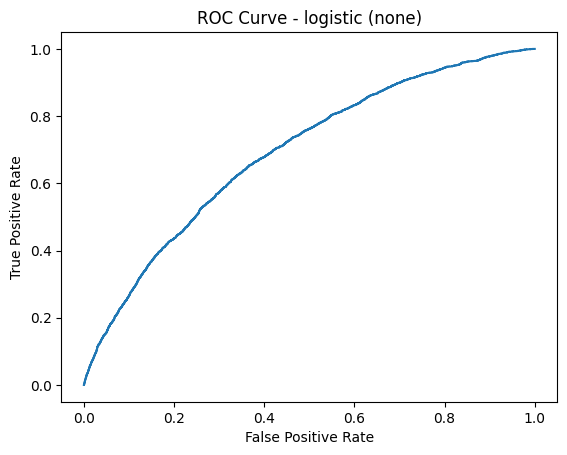


===== random_forest (none) =====
Accuracy:  0.8434
Precision: 0.4118
Recall:    0.0095
F1 Score:  0.0186
ROC AUC:   0.6711

Confusion Matrix:
[[15849    40]
 [ 2908    28]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91     15889
           1       0.41      0.01      0.02      2936

    accuracy                           0.84     18825
   macro avg       0.63      0.50      0.47     18825
weighted avg       0.78      0.84      0.78     18825



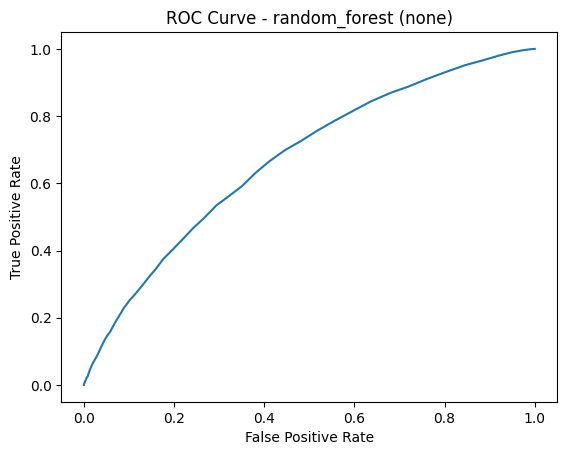


===== balanced_rf (none) =====
Accuracy:  0.6266
Precision: 0.2391
Recall:    0.6390
F1 Score:  0.3480
ROC AUC:   0.6789

Confusion Matrix:
[[9920 5969]
 [1060 1876]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.62      0.74     15889
           1       0.24      0.64      0.35      2936

    accuracy                           0.63     18825
   macro avg       0.57      0.63      0.54     18825
weighted avg       0.80      0.63      0.68     18825



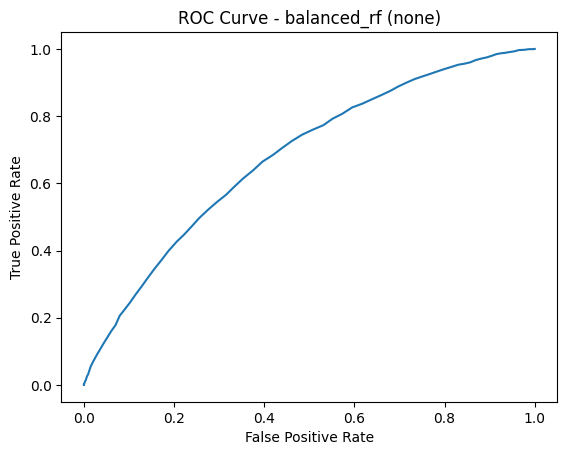


===== neural_net (none) =====
Accuracy:  0.8314
Precision: 0.2396
Recall:    0.0371
F1 Score:  0.0643
ROC AUC:   0.6464

Confusion Matrix:
[[15543   346]
 [ 2827   109]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91     15889
           1       0.24      0.04      0.06      2936

    accuracy                           0.83     18825
   macro avg       0.54      0.51      0.49     18825
weighted avg       0.75      0.83      0.78     18825



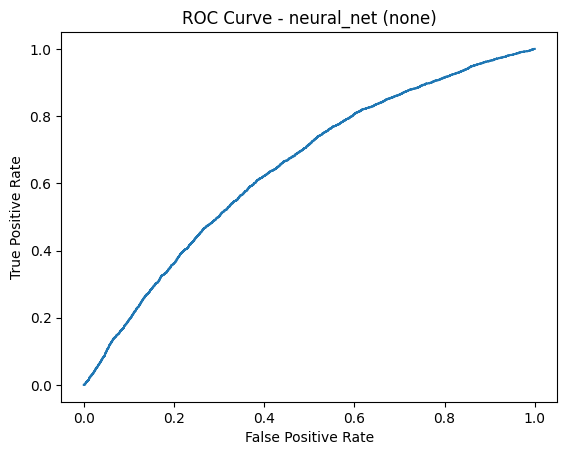


===== xgboost (none) =====
Accuracy:  0.8401
Precision: 0.3619
Recall:    0.0330
F1 Score:  0.0605
ROC AUC:   0.6755

Confusion Matrix:
[[15718   171]
 [ 2839    97]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.91     15889
           1       0.36      0.03      0.06      2936

    accuracy                           0.84     18825
   macro avg       0.60      0.51      0.49     18825
weighted avg       0.77      0.84      0.78     18825



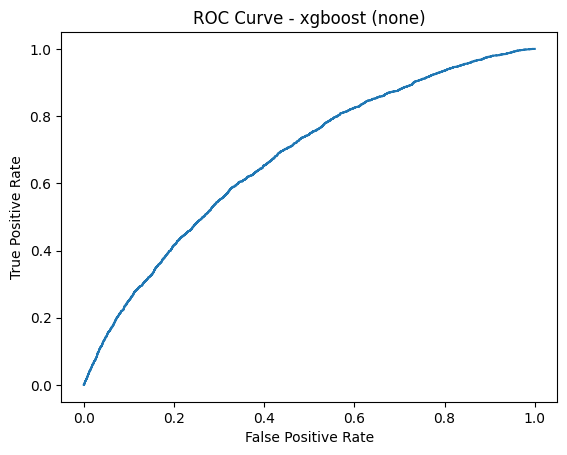


Sampler: smote

===== logistic (smote) =====
Accuracy:  0.6351
Precision: 0.2422
Recall:    0.6294
F1 Score:  0.3498
ROC AUC:   0.6832

Confusion Matrix:
[[10107  5782]
 [ 1088  1848]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.64      0.75     15889
           1       0.24      0.63      0.35      2936

    accuracy                           0.64     18825
   macro avg       0.57      0.63      0.55     18825
weighted avg       0.80      0.64      0.68     18825



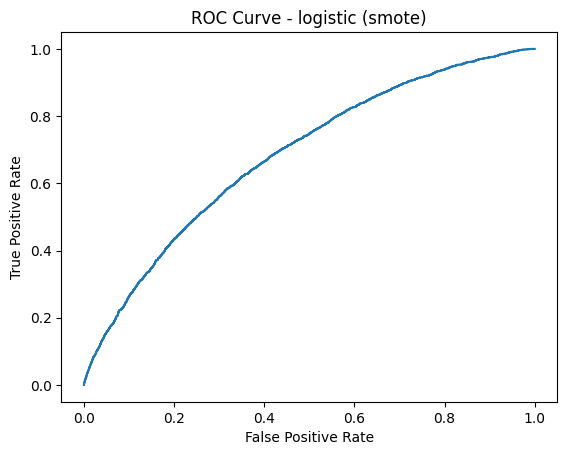


===== random_forest (smote) =====
Accuracy:  0.8327
Precision: 0.3494
Recall:    0.0841
F1 Score:  0.1356
ROC AUC:   0.6637

Confusion Matrix:
[[15429   460]
 [ 2689   247]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91     15889
           1       0.35      0.08      0.14      2936

    accuracy                           0.83     18825
   macro avg       0.60      0.53      0.52     18825
weighted avg       0.77      0.83      0.79     18825



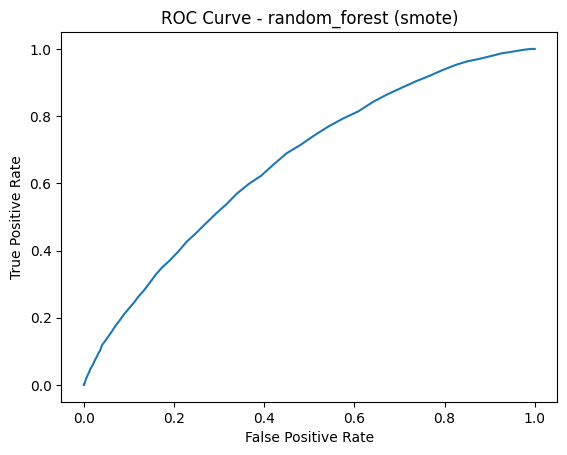


===== balanced_rf (smote) =====
Accuracy:  0.8319
Precision: 0.3343
Recall:    0.0783
F1 Score:  0.1269
ROC AUC:   0.6650

Confusion Matrix:
[[15431   458]
 [ 2706   230]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91     15889
           1       0.33      0.08      0.13      2936

    accuracy                           0.83     18825
   macro avg       0.59      0.52      0.52     18825
weighted avg       0.77      0.83      0.79     18825



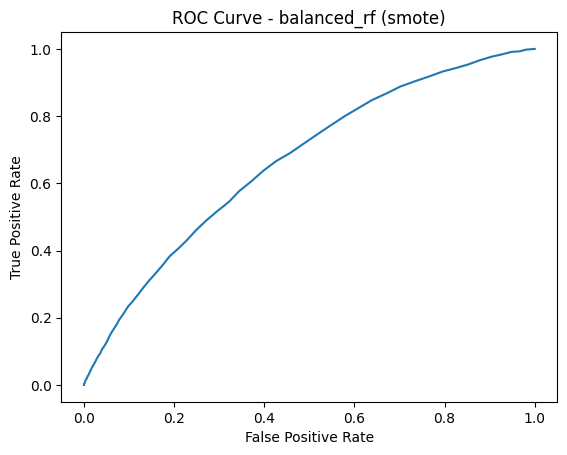


===== neural_net (smote) =====
Accuracy:  0.7503
Precision: 0.2623
Recall:    0.3314
F1 Score:  0.2928
ROC AUC:   0.6430

Confusion Matrix:
[[13152  2737]
 [ 1963   973]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85     15889
           1       0.26      0.33      0.29      2936

    accuracy                           0.75     18825
   macro avg       0.57      0.58      0.57     18825
weighted avg       0.78      0.75      0.76     18825



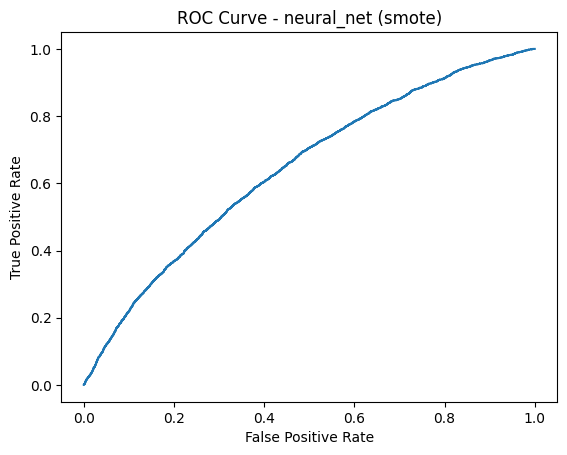


===== xgboost (smote) =====
Accuracy:  0.8404
Precision: 0.4023
Recall:    0.0484
F1 Score:  0.0863
ROC AUC:   0.6719

Confusion Matrix:
[[15678   211]
 [ 2794   142]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.91     15889
           1       0.40      0.05      0.09      2936

    accuracy                           0.84     18825
   macro avg       0.63      0.52      0.50     18825
weighted avg       0.78      0.84      0.78     18825



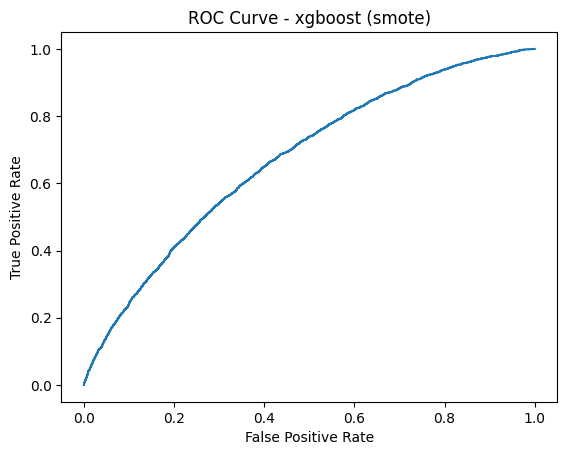


Sampler: oversample

===== logistic (oversample) =====
Accuracy:  0.6486
Precision: 0.2513
Recall:    0.6332
F1 Score:  0.3598
ROC AUC:   0.6913

Confusion Matrix:
[[10351  5538]
 [ 1077  1859]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.65      0.76     15889
           1       0.25      0.63      0.36      2936

    accuracy                           0.65     18825
   macro avg       0.58      0.64      0.56     18825
weighted avg       0.80      0.65      0.70     18825



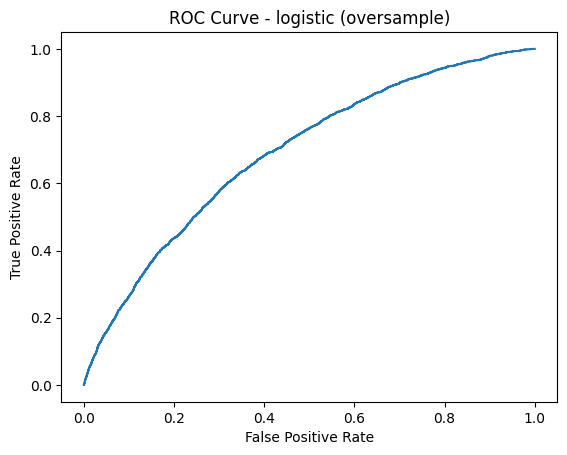


===== random_forest (oversample) =====
Accuracy:  0.8382
Precision: 0.3724
Recall:    0.0542
F1 Score:  0.0946
ROC AUC:   0.6748

Confusion Matrix:
[[15621   268]
 [ 2777   159]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91     15889
           1       0.37      0.05      0.09      2936

    accuracy                           0.84     18825
   macro avg       0.61      0.52      0.50     18825
weighted avg       0.77      0.84      0.78     18825



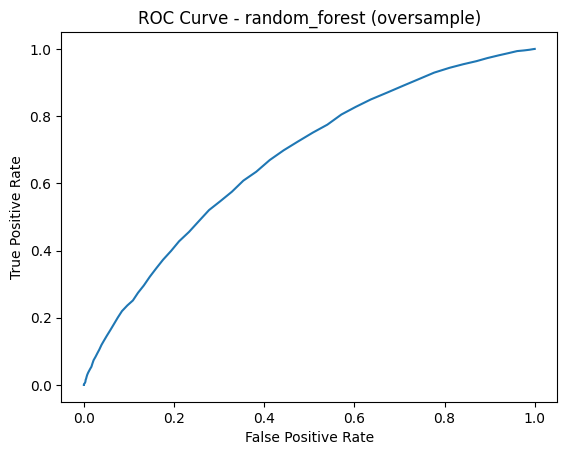


===== balanced_rf (oversample) =====
Accuracy:  0.8387
Precision: 0.3753
Recall:    0.0518
F1 Score:  0.0910
ROC AUC:   0.6716

Confusion Matrix:
[[15636   253]
 [ 2784   152]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91     15889
           1       0.38      0.05      0.09      2936

    accuracy                           0.84     18825
   macro avg       0.61      0.52      0.50     18825
weighted avg       0.78      0.84      0.78     18825



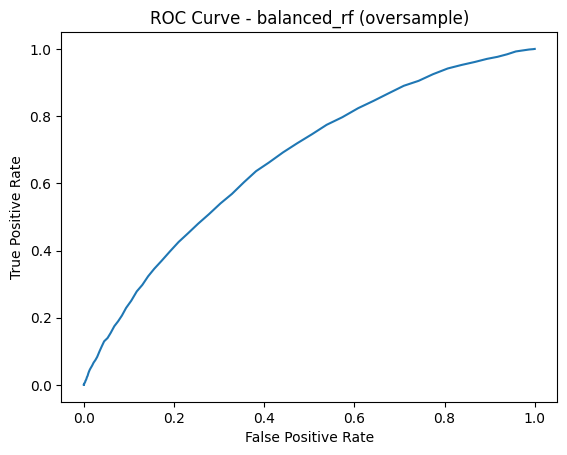


===== neural_net (oversample) =====
Accuracy:  0.5968
Precision: 0.2193
Recall:    0.6192
F1 Score:  0.3239
ROC AUC:   0.6448

Confusion Matrix:
[[9417 6472]
 [1118 1818]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.59      0.71     15889
           1       0.22      0.62      0.32      2936

    accuracy                           0.60     18825
   macro avg       0.56      0.61      0.52     18825
weighted avg       0.79      0.60      0.65     18825



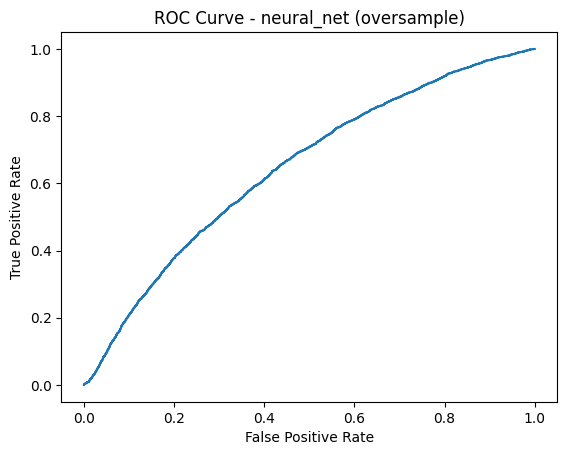


===== xgboost (oversample) =====
Accuracy:  0.6760
Precision: 0.2485
Recall:    0.5324
F1 Score:  0.3389
ROC AUC:   0.6644

Confusion Matrix:
[[11163  4726]
 [ 1373  1563]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.70      0.79     15889
           1       0.25      0.53      0.34      2936

    accuracy                           0.68     18825
   macro avg       0.57      0.62      0.56     18825
weighted avg       0.79      0.68      0.72     18825



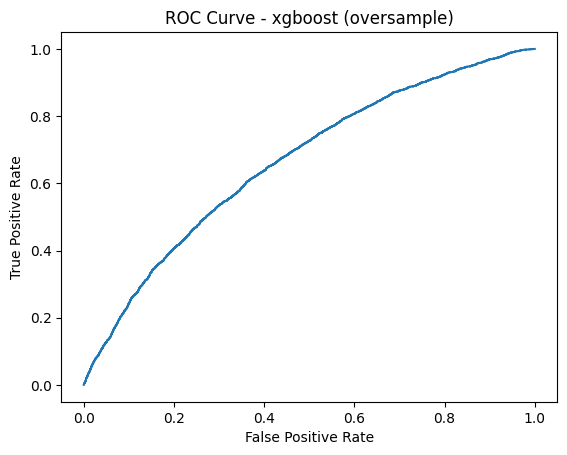


Sampler: undersample

===== logistic (undersample) =====
Accuracy:  0.6478
Precision: 0.2509
Recall:    0.6335
F1 Score:  0.3594
ROC AUC:   0.6912

Confusion Matrix:
[[10335  5554]
 [ 1076  1860]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.65      0.76     15889
           1       0.25      0.63      0.36      2936

    accuracy                           0.65     18825
   macro avg       0.58      0.64      0.56     18825
weighted avg       0.80      0.65      0.70     18825



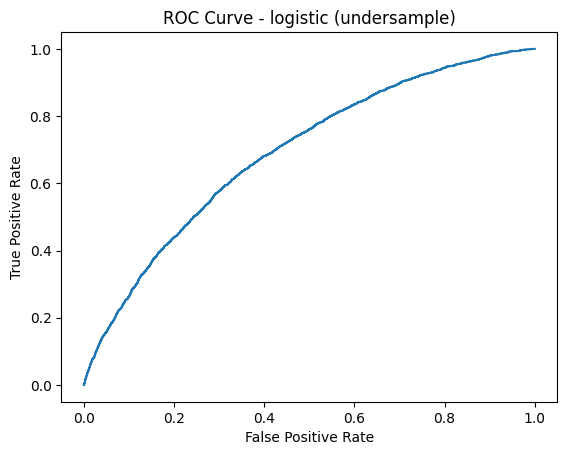


===== random_forest (undersample) =====
Accuracy:  0.6239
Precision: 0.2348
Recall:    0.6250
F1 Score:  0.3414
ROC AUC:   0.6751

Confusion Matrix:
[[9910 5979]
 [1101 1835]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.62      0.74     15889
           1       0.23      0.62      0.34      2936

    accuracy                           0.62     18825
   macro avg       0.57      0.62      0.54     18825
weighted avg       0.80      0.62      0.68     18825



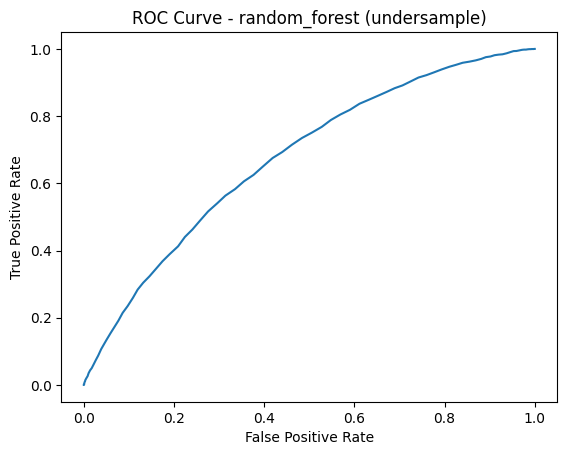


===== balanced_rf (undersample) =====
Accuracy:  0.6223
Precision: 0.2328
Recall:    0.6196
F1 Score:  0.3385
ROC AUC:   0.6754

Confusion Matrix:
[[9895 5994]
 [1117 1819]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.62      0.74     15889
           1       0.23      0.62      0.34      2936

    accuracy                           0.62     18825
   macro avg       0.57      0.62      0.54     18825
weighted avg       0.79      0.62      0.67     18825



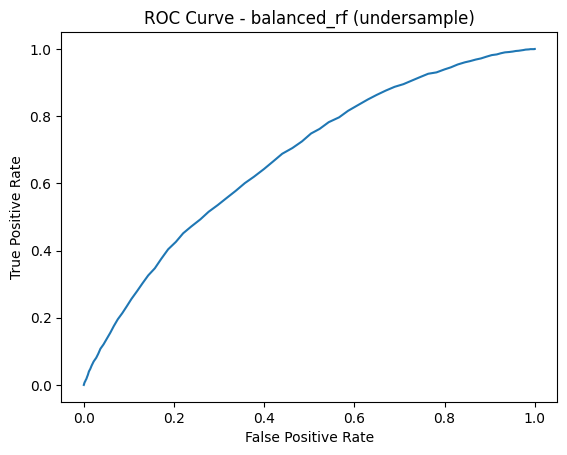


===== neural_net (undersample) =====
Accuracy:  0.5440
Precision: 0.2086
Recall:    0.6887
F1 Score:  0.3202
ROC AUC:   0.6346

Confusion Matrix:
[[8218 7671]
 [ 914 2022]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.52      0.66     15889
           1       0.21      0.69      0.32      2936

    accuracy                           0.54     18825
   macro avg       0.55      0.60      0.49     18825
weighted avg       0.79      0.54      0.60     18825



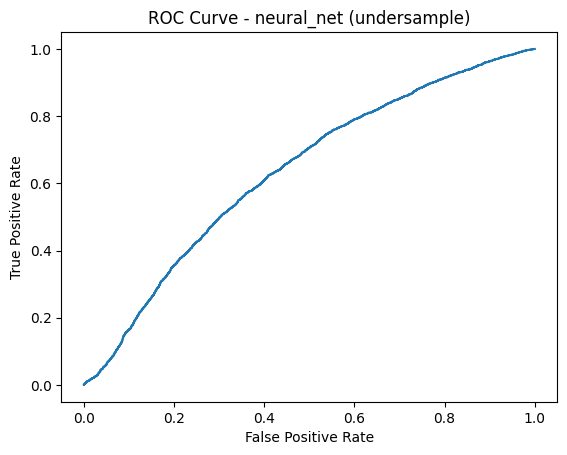


===== xgboost (undersample) =====
Accuracy:  0.6154
Precision: 0.2306
Recall:    0.6277
F1 Score:  0.3373
ROC AUC:   0.6664

Confusion Matrix:
[[9741 6148]
 [1093 1843]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.61      0.73     15889
           1       0.23      0.63      0.34      2936

    accuracy                           0.62     18825
   macro avg       0.56      0.62      0.53     18825
weighted avg       0.79      0.62      0.67     18825



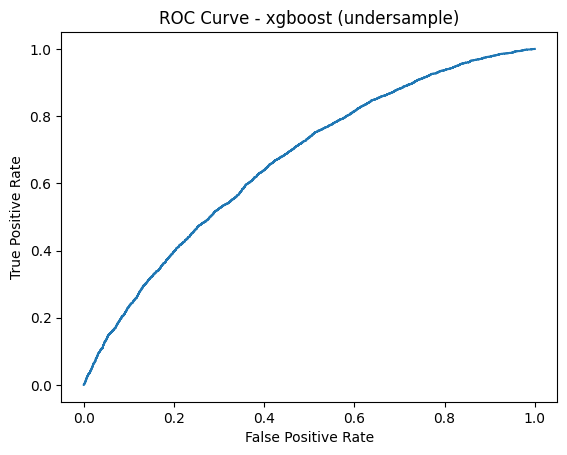


===== SUMMARY =====
                          Model  Accuracy  Precision    Recall        F1  \
0               logistic (none)  0.843506   0.462121  0.020777  0.039765   
1          random_forest (none)  0.843400   0.411765  0.009537  0.018642   
2            balanced_rf (none)  0.626614   0.239133  0.638965  0.348020   
3             neural_net (none)  0.831448   0.239560  0.037125  0.064288   
4                xgboost (none)  0.840106   0.361940  0.033038  0.060549   
5              logistic (smote)  0.635060   0.242202  0.629428  0.349801   
6         random_forest (smote)  0.832722   0.349364  0.084128  0.135603   
7           balanced_rf (smote)  0.831926   0.334302  0.078338  0.126932   
8            neural_net (smote)  0.750332   0.262264  0.331403  0.292808   
9               xgboost (smote)  0.840372   0.402266  0.048365  0.086348   
10        logistic (oversample)  0.648606   0.251318  0.633174  0.359818   
11   random_forest (oversample)  0.838247   0.372365  0.054155  0.0

In [50]:
# SAMPLERS 

samplers = {
    "none": None,
    "smote": SMOTE(random_state=42),
    "oversample": RandomOverSampler(random_state=42),
    "undersample": RandomUnderSampler(random_state=42)
}

# MODELS 
models = {
    "logistic": LogisticRegression(max_iter=1000),
    "random_forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "balanced_rf": BalancedRandomForestClassifier(random_state=42),
    "neural_net": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300),
    "xgboost": xgb.XGBClassifier(eval_metric="logloss", random_state=42)
}

#EVALUATION FUNCTION

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)

    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_te)[:, 1]
    else:
        y_probs = model.decision_function(X_te)

    acc = accuracy_score(y_te, y_pred)
    precision = precision_score(y_te, y_pred, zero_division=0)
    recall = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_probs)

    print(f"\n===== {name} =====")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC AUC:   {auc:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_te, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_te, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_te, y_probs)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }

# RUN EVERYTHING
results = []

for samp_name, sampler in samplers.items():
    print(f"\n==============================")
    print(f"Sampler: {samp_name}")
    print(f"==============================")

    # Step 2: apply sampler
    if sampler is not None:
        X_res, y_res = sampler.fit_resample(X_train, y_train)
    else:
        X_res, y_res = X_train, y_train

    for model_name, model in models.items():
        full_name = f"{model_name} ({samp_name})"

        metrics = evaluate_model(
            full_name,
            model,
            X_res,
            X_test,
            y_res,
            y_test
        )

        results.append(metrics)

# 6. SUMMARY
results_df = pd.DataFrame(results)

print("\n===== SUMMARY =====")
print(results_df)

print("\nSorted by AUC:")
print(results_df.sort_values(by="AUC", ascending=False))


In [51]:
results_df.to_csv("resampled_models_results.csv", index=False)

## Hyper and Post Tuning Optimization

In [52]:
# HYPERPARAMETER + THRESHOLD TUNING PIPELINE


Best Params:
 {'C': 0.01, 'penalty': 'l2', 'solver': 'saga', 'f1_mean': 0.3607669616519174, 'auc_mean': 0.6955704048600373, 'best_threshold': 0.5}

Final Metrics:
        accuracy    recall  precision        f1       auc
train  0.654289  0.628175   0.253999  0.361733  0.696550
val    0.650146  0.639986   0.253645  0.363302  0.694845
test   0.648659  0.630790   0.250881  0.358984  0.690497


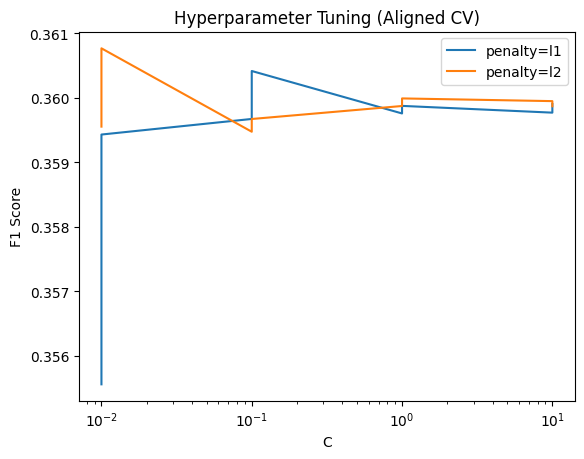

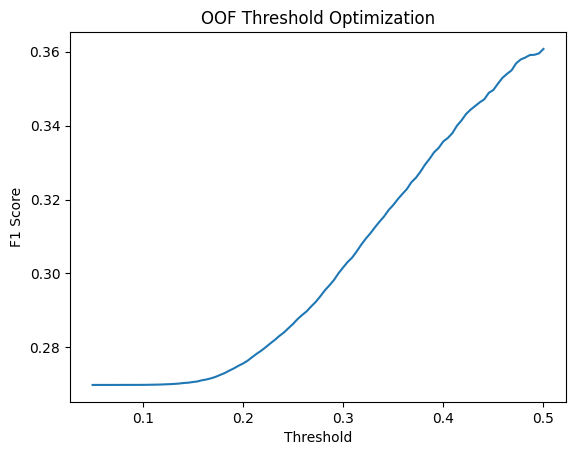

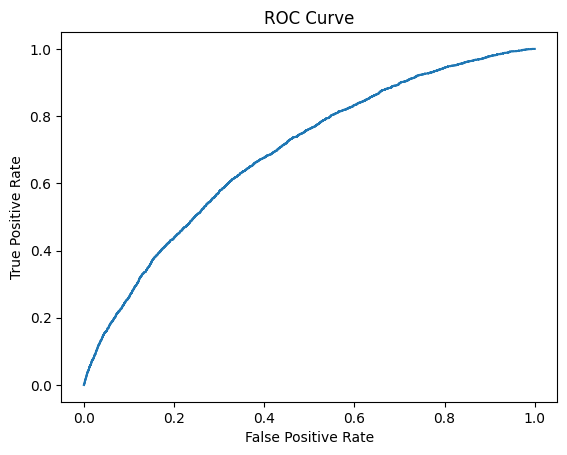

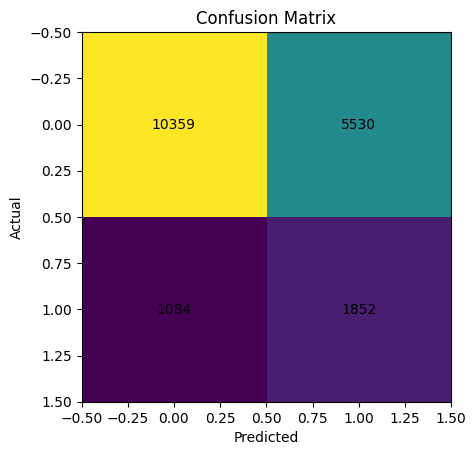

In [53]:
#SETUP, explain each paramter and possible values
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GRID SEARCH WITH OUT OF FOLD PREDICTIONS
#wtf is an off prediction
results = []
best_global = None
best_oof_probs = None
best_oof_true = None

for C in param_grid["C"]:
    for penalty in param_grid["penalty"]:
        for solver in param_grid["solver"]:

            if penalty == "l1" and solver not in ["liblinear", "saga"]:
                continue

            pipeline = Pipeline([
                ('rus', RandomUnderSampler(random_state=42)),
                ('model', LogisticRegression(
                    C=C,
                    penalty=penalty,
                    solver=solver,
                    max_iter=2000
                ))
            ])

            oof_probs = np.zeros(len(y_train))
            oof_true = np.array(y_train)

            for train_idx, val_idx in cv.split(X_train, y_train):
                X_tr, X_val_cv = X_train.iloc[train_idx], X_train.iloc[val_idx]
                y_tr, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

                pipeline.fit(X_tr, y_tr)
                probs = pipeline.predict_proba(X_val_cv)[:, 1]
                oof_probs[val_idx] = probs

            # Tune threshold on OOF predictions
            thresholds = np.linspace(0.05, 0.5, 100)
            f1s = []

            for t in thresholds:
                preds = (oof_probs >= t).astype(int)
                f1s.append(f1_score(oof_true, preds))

            best_idx = np.argmax(f1s)
            best_t = thresholds[best_idx]
            best_f1 = f1s[best_idx]

            results.append({
                "C": C,
                "penalty": penalty,
                "solver": solver,
                "f1_mean": best_f1,
                "auc_mean": roc_auc_score(oof_true, oof_probs),
                "best_threshold": best_t
            })

            # Track best model globally
            if best_global is None or best_f1 > best_global["f1_mean"]:
                best_global = results[-1]
                best_oof_probs = oof_probs.copy()
                best_oof_true = oof_true.copy()

results_df = pd.DataFrame(results)
results_df.to_csv("logistic_hyperparameter_results.csv", index=False)

print("\nBest Params:\n", best_global)

# TRAIN FINAL MODEL

final_pipeline = Pipeline([
    ('rus', RandomUnderSampler(random_state=42)),
    ('model', LogisticRegression(
        C=best_global["C"],
        penalty=best_global["penalty"],
        solver=best_global["solver"],
        max_iter=2000
    ))
])

final_pipeline.fit(X_train, y_train)

best_threshold = best_global["best_threshold"]

# EVALUATION FUNCTION
def evaluate(model, X, y, threshold):
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y, preds),
        "recall": recall_score(y, preds),
        "precision": precision_score(y, preds),
        "f1": f1_score(y, preds),
        "auc": roc_auc_score(y, probs)
    }

train_metrics = evaluate(final_pipeline, X_train, y_train, best_threshold)
val_metrics   = evaluate(final_pipeline, X_val, y_val, best_threshold)
test_metrics  = evaluate(final_pipeline, X_test, y_test, best_threshold)

metrics_df = pd.DataFrame([train_metrics, val_metrics, test_metrics],
                         index=["train", "val", "test"])
metrics_df.to_csv("final_model_metrics_clean.csv")

print("\nFinal Metrics:\n", metrics_df)

# VISUALIZATIONS

# F1 vs C
plt.figure()
for penalty in results_df["penalty"].unique():
    subset = results_df[results_df["penalty"] == penalty]
    plt.plot(subset["C"], subset["f1_mean"], label=f"penalty={penalty}")

plt.xlabel("C")
plt.ylabel("F1 Score")
plt.title("Hyperparameter Tuning (Aligned CV)")
plt.legend()
plt.xscale("log")
plt.show()

# Threshold curve (best model)
thresholds = np.linspace(0.05, 0.5, 100)
f1s = [f1_score(best_oof_true, (best_oof_probs >= t).astype(int)) for t in thresholds]

plt.figure()
plt.plot(thresholds, f1s)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("OOF Threshold Optimization")
plt.show()

# ROC Curve
probs = final_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, (probs >= best_threshold).astype(int))

plt.figure()
plt.imshow(cm)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [54]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
rus = RandomUnderSampler(random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):

    X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # -----------------------------
    # UNDERSAMPLE ONLY TRAIN FOLD
    # -----------------------------
    X_tr_res, y_tr_res = rus.fit_resample(X_tr, y_tr)

    # fresh model each fold
    model = LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='liblinear',
        max_iter=1000
    )

    model.fit(X_tr_res, y_tr_res)

    probs = model.predict_proba(X_va)[:, 1]
    preds = (probs >= 0.5).astype(int)

    cv_results.append({
        "fold": fold + 1,
        "accuracy": accuracy_score(y_va, preds),
        "recall": recall_score(y_va, preds),
        "precision": precision_score(y_va, preds),
        "f1": f1_score(y_va, preds),
        "auc": roc_auc_score(y_va, probs)
    })

cv_df = pd.DataFrame(cv_results)

print(cv_df)
print("\nCV Summary:")
print(cv_df.describe())

   fold  accuracy    recall  precision        f1       auc
0     1  0.655492  0.613869   0.251910  0.357226  0.690110
1     2  0.652362  0.627737   0.252644  0.360285  0.699173
2     3  0.656801  0.627007   0.255427  0.362983  0.701991
3     4  0.647846  0.645255   0.253186  0.363674  0.701097
4     5  0.650407  0.617153   0.249263  0.355103  0.686443

CV Summary:
           fold  accuracy    recall  precision        f1       auc
count  5.000000  5.000000  5.000000   5.000000  5.000000  5.000000
mean   3.000000  0.652582  0.626204   0.252486  0.359854  0.695763
std    1.581139  0.003657  0.012248   0.002230  0.003676  0.007030
min    1.000000  0.647846  0.613869   0.249263  0.355103  0.686443
25%    2.000000  0.650407  0.617153   0.251910  0.357226  0.690110
50%    3.000000  0.652362  0.627007   0.252644  0.360285  0.699173
75%    4.000000  0.655492  0.627737   0.253186  0.362983  0.701097
max    5.000000  0.656801  0.645255   0.255427  0.363674  0.701991


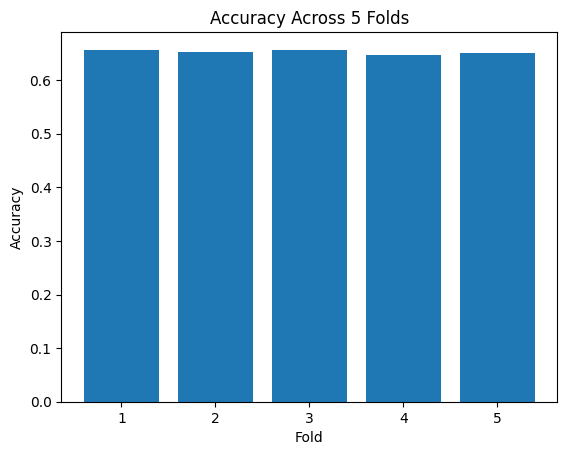

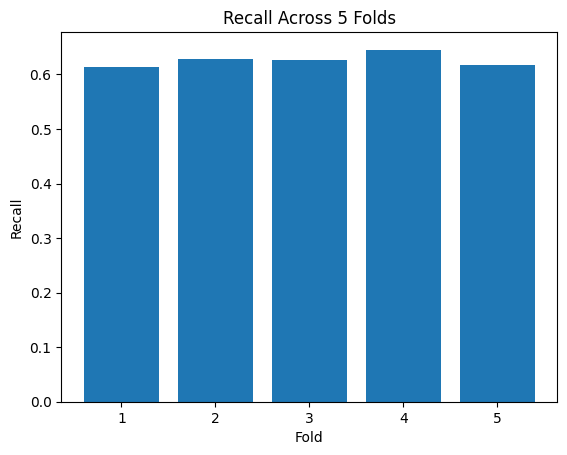

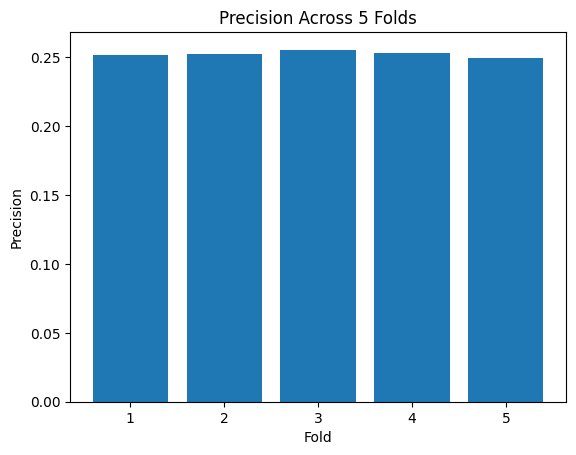

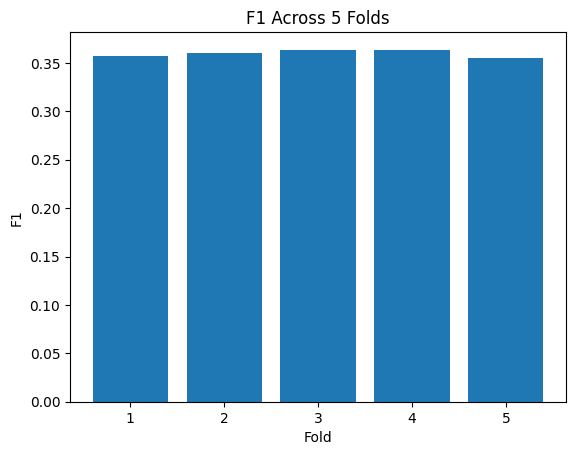

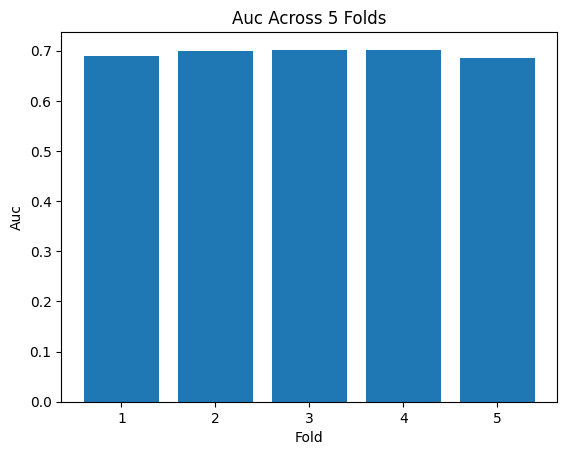

In [55]:
metrics = ["accuracy", "recall", "precision", "f1", "auc"]

for metric in metrics:
    plt.figure()
    plt.bar(cv_df["fold"], cv_df[metric])
    plt.xlabel("Fold")
    plt.ylabel(metric.capitalize())
    plt.title(f"{metric.capitalize()} Across 5 Folds")
    plt.show()

#### Professor requested we run a model with threshhold set to reflect the split in class labels + do not resample the data to see if that our performs a model with undersampling



In [56]:
# STATS MODELS FOR SIGNIFICANCE 
X_train_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()

p_values = result.pvalues.drop("const")

alpha = 0.05
insignificant_features = p_values[p_values > alpha].index.tolist()

print("Insignificant features:", insignificant_features)

# REDUCE DATA 
X_train_sig = X_train.drop(columns=insignificant_features)
X_test_sig = X_test.drop(columns=insignificant_features)

# TRAIN SKLEARN MODEL 
log_model_sig = LogisticRegression(max_iter=1000)
log_model_sig.fit(X_train_sig, y_train)

# THRESHOLD 
threshold = y_train.mean()

#  PREDICTIONS 
y_probs_sig = log_model_sig.predict_proba(X_test_sig)[:, 1]
y_pred_sig = (y_probs_sig >= threshold).astype(int)

# EVALUATION 
print("Threshold:", threshold)
print("Accuracy:", accuracy_score(y_test, y_pred_sig))
print("Recall:", recall_score(y_test, y_pred_sig))
print("Precision:", precision_score(y_test, y_pred_sig))
print("F1:", f1_score(y_test, y_pred_sig))
print("ROC-AUC:", roc_auc_score(y_test, y_probs_sig))

#OVERFITTING CHECK

# Train predictions
y_probs_train = log_model_sig.predict_proba(X_train_sig)[:, 1]
y_pred_train = (y_probs_train >= threshold).astype(int)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_sig)
gap = train_acc - test_acc

print("\n--- Overfitting Check ---")
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Accuracy Gap:", gap)


### it does not outperform resmapled data. keep this metrics for justification


Optimization terminated successfully.
         Current function value: 0.400797
         Iterations 6
Insignificant features: ['credit_history_months', 'loan_amnt', 'delinq_2yrs', 'home_ownership_NONE', 'home_ownership_OWN', 'verification_status_Source Verified', 'purpose_credit_card', 'purpose_house', 'purpose_major_purchase', 'purpose_moving', 'purpose_wedding', 'initial_list_status_w']
Threshold: 0.15595118841635552
Accuracy: 0.6476494023904382
Recall: 0.6314713896457765
Precision: 0.25037137069547605
F1: 0.35857267188859876
ROC-AUC: 0.6914718346608616

--- Overfitting Check ---
Train Accuracy: 0.6538452782078135
Test Accuracy: 0.6476494023904382
Accuracy Gap: 0.00619587581737524


In [57]:
# Bert Modelling

In [58]:
# SECTION 1: Preparing
# Configuration (otherwise bert will take a lot of space)
SAMPLE_SIZE    = 25000
PCA_COMPONENTS = 80
BERT_MAX_LEN   = 128
RANDOM_STATE   = 42

# Putting baseline copy in loan_df for easier access.
loan_df = baseline_bert_df.copy()
loan_df = loan_df.drop(columns=['installment', 'interest_burden', 'grade'])

# Creatign a sample
sample_n = min(SAMPLE_SIZE, len(loan_df))
loan_df, _ = train_test_split(loan_df, train_size=sample_n,
                              random_state=RANDOM_STATE, stratify=loan_df['loan_risk'])
loan_df.reset_index(drop=True, inplace=True)


In [59]:

# SECTION 2: Encoding

text_data = loan_df['desc'].tolist()
num_features = loan_df.drop(columns=['desc', 'loan_risk']).copy()

cat_cols = num_features.select_dtypes(include=['object','category']).columns.tolist()
for col in cat_cols:
    num_features[col] = LabelEncoder().fit_transform(num_features[col].astype(str))

target_map = {'Defaulted': 1, 'Paid': 0}
y_bert = loan_df['loan_risk'].map(target_map).values

num_features = num_features.values

# SECTION 3: Splitting

idx = np.arange(len(y_bert))

idx_trainval, idx_test, y_bert_trainval, y_bert_test = train_test_split(
    idx, y_bert, test_size=0.20, random_state=RANDOM_STATE, stratify=y_bert
)
idx_train, idx_val, y_bert_train, y_bert_val = train_test_split(
    idx_trainval, y_bert_trainval, test_size=0.25,
    random_state=RANDOM_STATE, stratify=y_bert_trainval
)


In [60]:

# SECTION 4: FinBERT

tokenizer  = AutoTokenizer.from_pretrained("ProsusAI/finbert")
bert_model = AutoModel.from_pretrained("ProsusAI/finbert").to("cpu") # please switch to cuda, if you have gpu on your pc
bert_model.eval()

def get_embeddings_batched(texts, batch_size=32):

    all_emb = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            batch, return_tensors="pt", truncation=True,
            padding=True, max_length=BERT_MAX_LEN
        ).to("cpu")

        with torch.no_grad():
            outputs = bert_model(**inputs)

        hidden = outputs.last_hidden_state
        mask   = inputs['attention_mask'].unsqueeze(-1).float()

        # Masked mean pool — ignores padding tokens
        mean_pool = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        cls_pool  = hidden[:, 0, :]

        combined = torch.cat([cls_pool, mean_pool], dim=1)
        all_emb.append(combined.cpu().numpy())

    return np.vstack(all_emb)

all_embeddings = get_embeddings_batched(text_data)

emb_train = all_embeddings[idx_train]
emb_val   = all_embeddings[idx_val]
emb_test  = all_embeddings[idx_test]

# SECTIoN 5: PCA

pca = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_STATE)
emb_train_pca = pca.fit_transform(emb_train)
emb_val_pca   = pca.transform(emb_val)
emb_test_pca  = pca.transform(emb_test)

explained_var = np.sum(pca.explained_variance_ratio_)

# SECTION 6: Scaling

scaler = StandardScaler()
num_train = scaler.fit_transform(num_features[idx_train])
num_val   = scaler.transform(num_features[idx_val])
num_test  = scaler.transform(num_features[idx_test])

# Combinign all
X_bert_train = np.hstack([emb_train_pca, num_train])
X_bert_val   = np.hstack([emb_val_pca,   num_val])
X_bert_test  = np.hstack([emb_test_pca,  num_test])

In [61]:

# SECTION 7: Putting XgBoost on top of Bert results
# Count actual class distribution
n_pos = int(sum(y_bert_train))
n_neg = len(y_bert_train) - n_pos

# scale_pos_weight should weight the MINORITY class up
# Formula: n_neg / n_pos weights positives more when positives are minority
# If positives are majority (as in your case), this gives a value < 1
# which is correct — it downweights the majority class
pos_weight_ratio = n_neg / n_pos

# If the minority class is NEGATIVE (your case), consider inverting the problem
# OR use ratio as-is but be aware the model naturally leans toward positives
if pos_weight_ratio < 0.5:
    print("WARNING: Positive class is the MAJORITY. "
          "Model may collapse to always-positive without careful tuning.")

xgb_final = XGBClassifier(
    max_depth         = 5,
    subsample         = 0.8,
    colsample_bytree  = 0.7,
    min_child_weight  = 8,
    learning_rate     = 0.03,
    n_estimators      = 1500,
    reg_alpha         = 0.5,
    reg_lambda        = 3.0,
    gamma             = 0.2,
    scale_pos_weight  = pos_weight_ratio,
    tree_method       = 'hist',
    eval_metric       = 'auc',
    early_stopping_rounds = 50,
    random_state      = RANDOM_STATE,
    n_jobs            = -1
)

xgb_final.fit(X_bert_train, y_bert_train, eval_set=[(X_bert_val, y_bert_val)], verbose=False)

# CALIBRATION if needed
# Raw XGBoost probabilities
raw_val_prob = xgb_final.predict_proba(X_bert_val)[:, 1]
raw_val_auc = roc_auc_score(y_bert_val, raw_val_prob)

# Try calibration
calibrated = CalibratedClassifierCV(xgb_final, method='isotonic', cv='prefit')
calibrated.fit(X_bert_val, y_bert_val)
cal_val_prob = calibrated.predict_proba(X_bert_val)[:, 1]
cal_val_auc = roc_auc_score(y_bert_val, cal_val_prob)

# Keep whichever is better
if cal_val_auc >= raw_val_auc:
    predictor = calibrated
else:
    predictor = xgb_final

train_prob = predictor.predict_proba(X_bert_train)[:, 1]
val_prob   = predictor.predict_proba(X_bert_val)[:, 1]
test_prob  = predictor.predict_proba(X_bert_test)[:, 1]

   Metric  Train Validation   Test Gap(Tr-Val) Gap(Tr-Test)
 Accuracy 0.7130     0.6918 0.6872     +0.0212      +0.0258
Precision 0.2999     0.2684 0.2636     +0.0315      +0.0363
   Recall 0.6298     0.5654 0.5603     +0.0644      +0.0695
       F1 0.4063     0.3640 0.3585     +0.0423      +0.0478
      AUC 0.7456     0.6926 0.6902     +0.0530      +0.0555


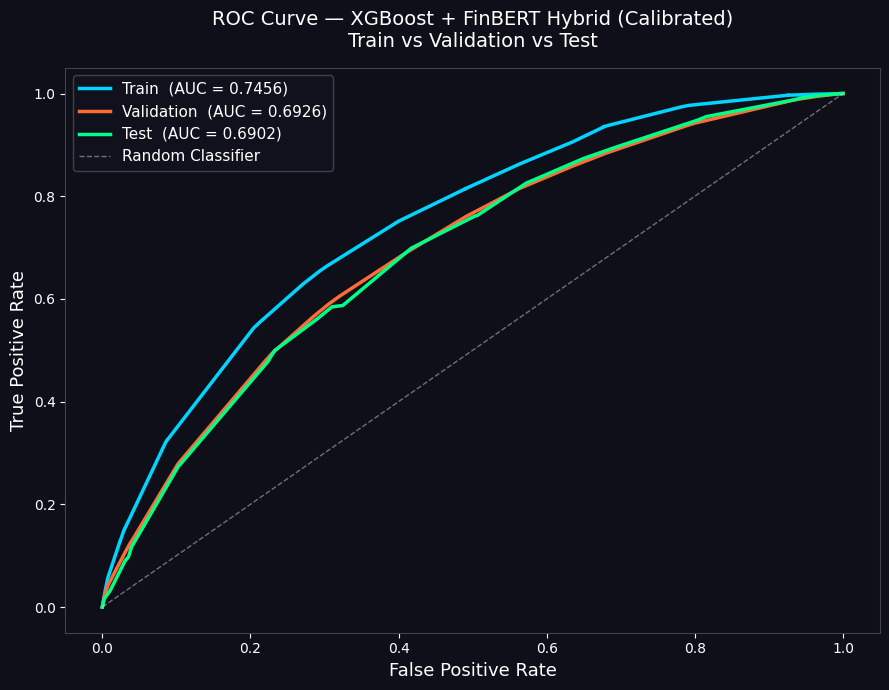

In [62]:

# SECTION 8: Threshold tuning

precisions, recalls, thresholds = precision_recall_curve(y_bert_val, val_prob)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)

# SANITY FLOOR: reject thresholds that predict >95% or <5% of val as positive
val_pos_rate_at_each = [(val_prob >= t).mean() for t in thresholds]
valid_mask = np.array([(0.05 < r < 0.95) for r in val_pos_rate_at_each])

if valid_mask.any():
    valid_f1 = np.where(valid_mask, f1_scores[:-1], -1)
    best_idx = int(np.argmax(valid_f1))
    best_thresh = thresholds[best_idx]
else:
    best_thresh = 0.5

train_pred = (train_prob >= best_thresh).astype(int)
val_pred   = (val_prob   >= best_thresh).astype(int)
test_pred  = (test_prob  >= best_thresh).astype(int)

# SECTION 9: Performance

def compute_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'AUC':       roc_auc_score(y_true, y_prob),
    }

m_train = compute_metrics(y_bert_train, train_pred, train_prob)
m_val   = compute_metrics(y_bert_val,   val_pred,   val_prob)
m_test  = compute_metrics(y_bert_test,  test_pred,  test_prob)

metrics_df = pd.DataFrame({
    'Metric':       list(m_train.keys()),
    'Train':        [f"{v:.4f}" for v in m_train.values()],
    'Validation':   [f"{v:.4f}" for v in m_val.values()],
    'Test':         [f"{v:.4f}" for v in m_test.values()],
    'Gap(Tr-Val)':  [f"{m_train[k]-m_val[k]:+.4f}"  for k in m_train],
    'Gap(Tr-Test)': [f"{m_train[k]-m_test[k]:+.4f}" for k in m_train],
})

print(metrics_df.to_string(index=False))

# Confusion matrixes

cm_dict = {}
for split_name, y_true, y_pred in [
    ("TRAIN", y_bert_train, train_pred),
    ("VALIDATION", y_bert_val, val_pred),
    ("TEST", y_bert_test, test_pred),
]:
    cm = confusion_matrix(y_true, y_pred)
    cm_dict[split_name] = cm

# ROC Curve
fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

colors = {'Train': '#00d4ff', 'Validation': '#ff6b35', 'Test': '#00ff88'}

for split_name, y_true, y_prob in [
    ('Train',      y_bert_train, train_prob),
    ('Validation', y_bert_val,   val_prob),
    ('Test',       y_bert_test,  test_prob),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, color=colors[split_name], linewidth=2.5,
            label=f'{split_name}  (AUC = {auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'w--', linewidth=1, alpha=0.4, label='Random Classifier')
ax.set_xlabel('False Positive Rate', color='white', fontsize=13)
ax.set_ylabel('True Positive Rate', color='white', fontsize=13)
ax.set_title('ROC Curve — XGBoost + FinBERT Hybrid (Calibrated)\nTrain vs Validation vs Test',
             color='white', fontsize=14, pad=15)
ax.legend(framealpha=0.2, facecolor='#1a1a2e', edgecolor='white',
          labelcolor='white', fontsize=11)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')

plt.tight_layout()
plt.savefig('ROC_Combined_Train_Val_Test.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

In [63]:

# SAVING RESULTS
filename = "XGBoost_FinBERT_Report.xlsx"
with pd.ExcelWriter(filename, engine='openpyxl') as writer:
    metrics_df.to_excel(writer, sheet_name='Metrics_All_Splits', index=False)

    for split_name, cm in cm_dict.items():
        pd.DataFrame(cm, index=['Actual_Neg','Actual_Pos'],
                         columns=['Pred_Neg','Pred_Pos']
                    ).to_excel(writer, sheet_name=f'CM_{split_name}')

    params_df = pd.DataFrame(list(xgb_final.get_params().items()),
                             columns=['Parameter', 'Value'])
    params_df['Value'] = params_df['Value'].astype(str)
    params_df.to_excel(writer, sheet_name='HyperParams', index=False)

    config_df = pd.DataFrame({
        'Setting': ['Sample Size', 'PCA Components', 'BERT Max Length',
                    'Best Threshold (F1)', 'Best XGB Iteration',
                    'PCA Variance Retained'],
        'Value':   [sample_n, PCA_COMPONENTS, BERT_MAX_LEN,
                    f"{best_thresh:.4f}", xgb_final.best_iteration,
                    f"{explained_var:.2%}"]
    })
    config_df.to_excel(writer, sheet_name='Config', index=False)

### more graphs

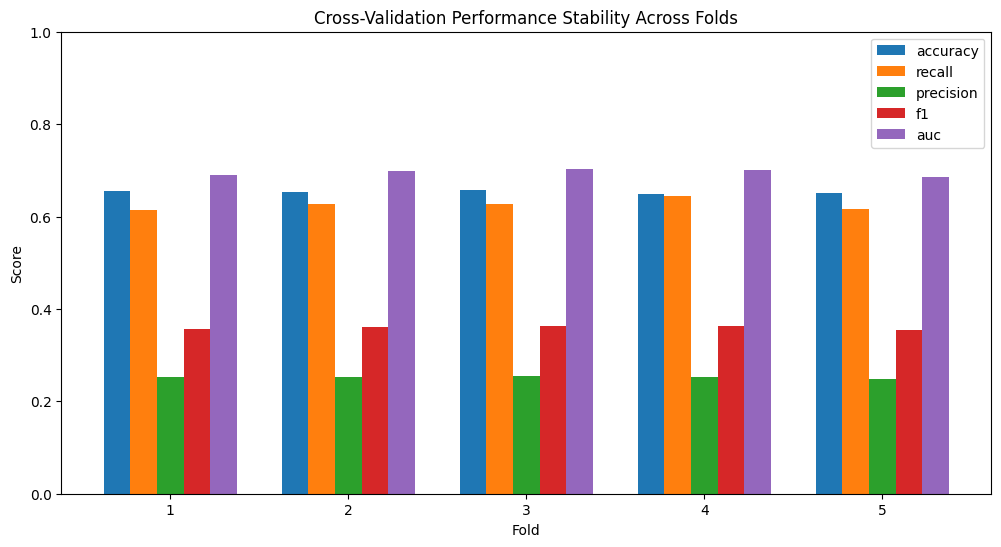

In [64]:
metrics = ["accuracy", "recall", "precision", "f1", "auc"]

# setup
folds = cv_df["fold"].values
x = np.arange(len(folds))  # fold positions
width = 0.15               # bar width

plt.figure(figsize=(12, 6))

# Plot each metric as a grouped bar
for i, metric in enumerate(metrics):
    plt.bar(
        x + i * width,
        cv_df[metric],
        width=width,
        label=metric
    )

# Formatting 
plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("Cross-Validation Performance Stability Across Folds")
plt.xticks(x + width * 2, folds)  # center tick labels
plt.legend()
plt.ylim(0, 1)

plt.savefig("cv_metrics_stability_across_folds.png", dpi=300, bbox_inches="tight")
plt.show()

In [65]:
### feature importance

# Extract feature names from pipeline 
feature_names = X_train.columns  

# Extract coefficients from trained logistic model 
model = final_pipeline.named_steps["model"]
coefficients = model.coef_[0]

# Build dataframe 
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
})

# Sort by importance 
feat_imp = feat_imp.sort_values("abs_coefficient", ascending=False)

# Save full table
feat_imp.to_csv("logistic_feature_importance.csv", index=False)

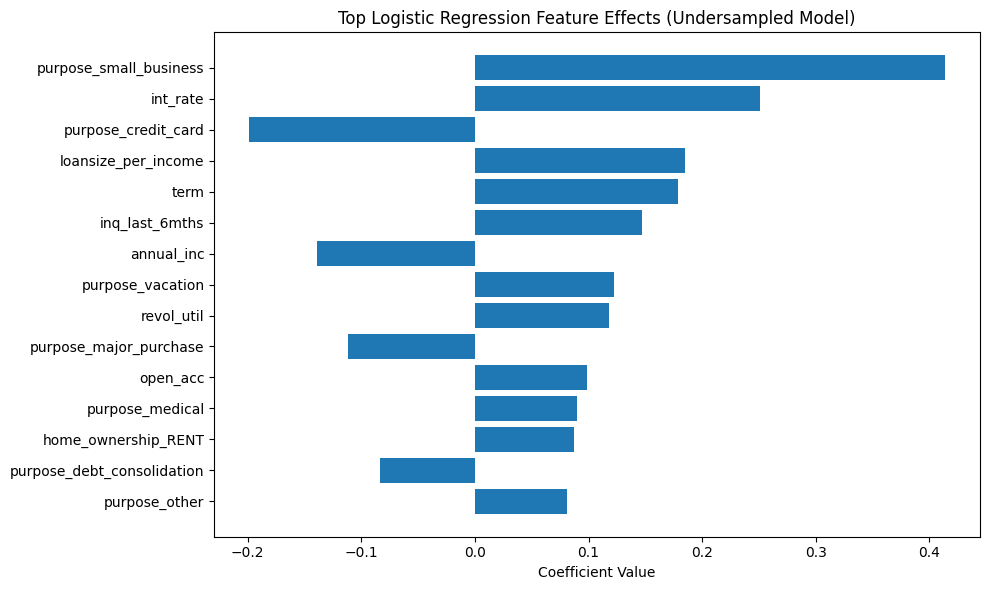

In [66]:
top_n = 15

top_features = feat_imp.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["coefficient"])
plt.xlabel("Coefficient Value")
plt.title("Top Logistic Regression Feature Effects (Undersampled Model)")
plt.tight_layout()

plt.savefig("logistic_top_features.png", dpi=300, bbox_inches="tight")
plt.show()

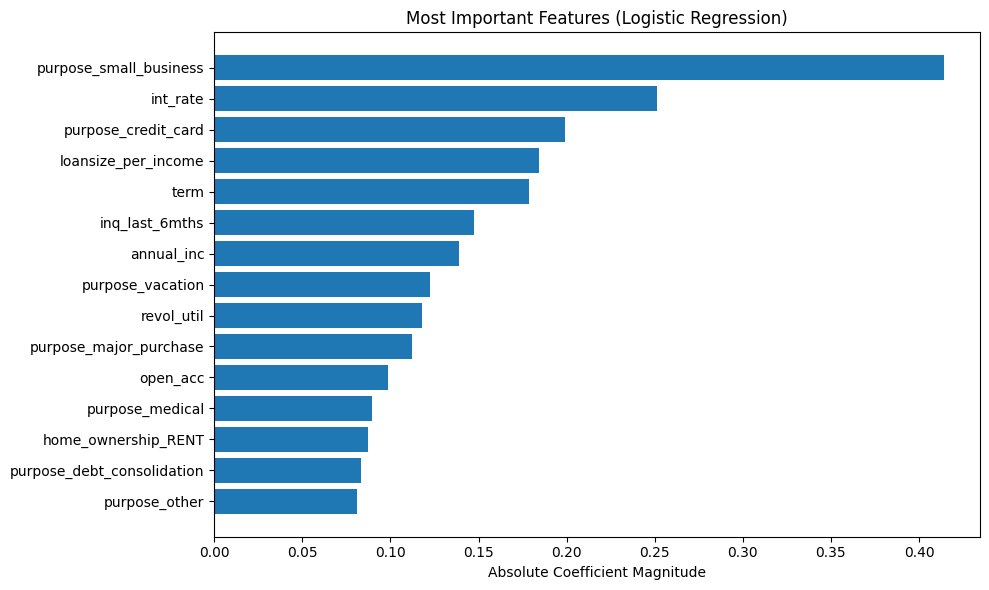

In [67]:
top_n = 15

top_abs = feat_imp.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(top_abs["feature"], top_abs["abs_coefficient"])
plt.xlabel("Absolute Coefficient Magnitude")
plt.title("Most Important Features (Logistic Regression)")
plt.tight_layout()

plt.savefig("logistic_feature_importance_abs.png", dpi=300, bbox_inches="tight")
plt.show()

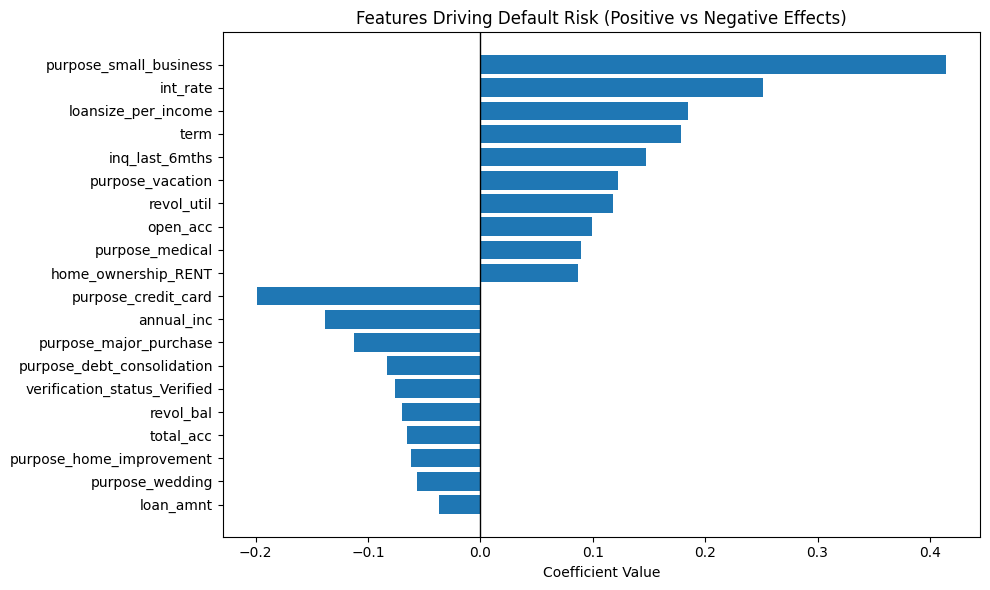

In [68]:
top_pos = feat_imp.sort_values("coefficient", ascending=False).head(10)
top_neg = feat_imp.sort_values("coefficient", ascending=True).head(10)

combined = pd.concat([top_pos, top_neg]).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(combined["feature"], combined["coefficient"])
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Coefficient Value")
plt.title("Features Driving Default Risk (Positive vs Negative Effects)")
plt.tight_layout()

plt.savefig("logistic_feature_direction.png", dpi=300, bbox_inches="tight")
plt.show()

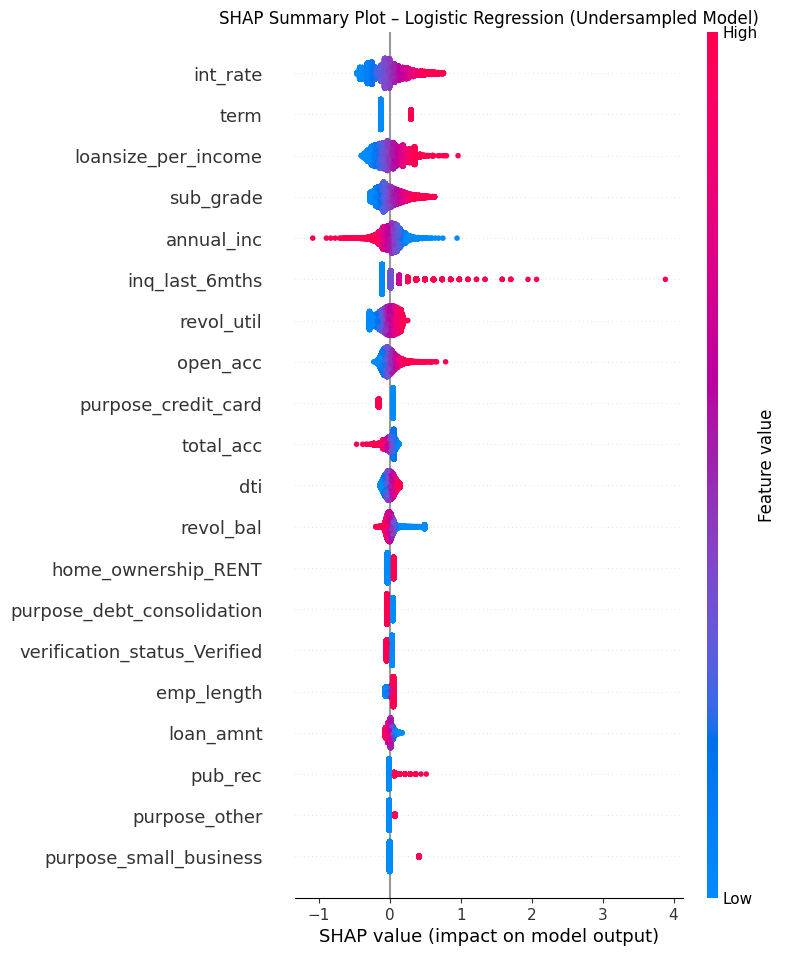

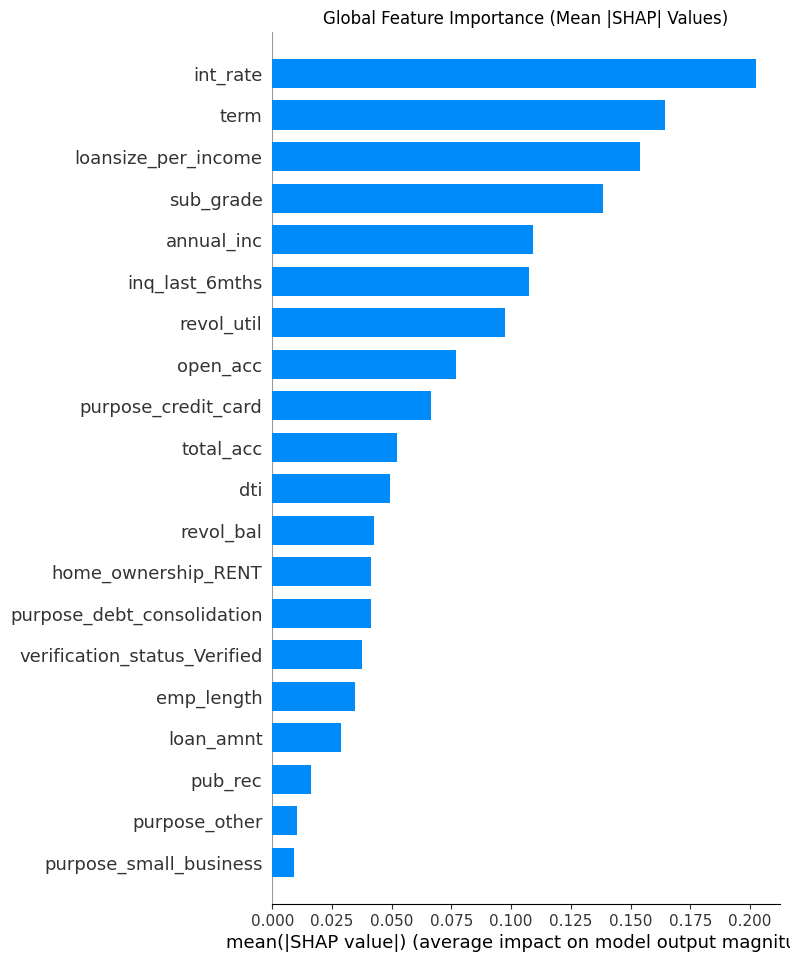

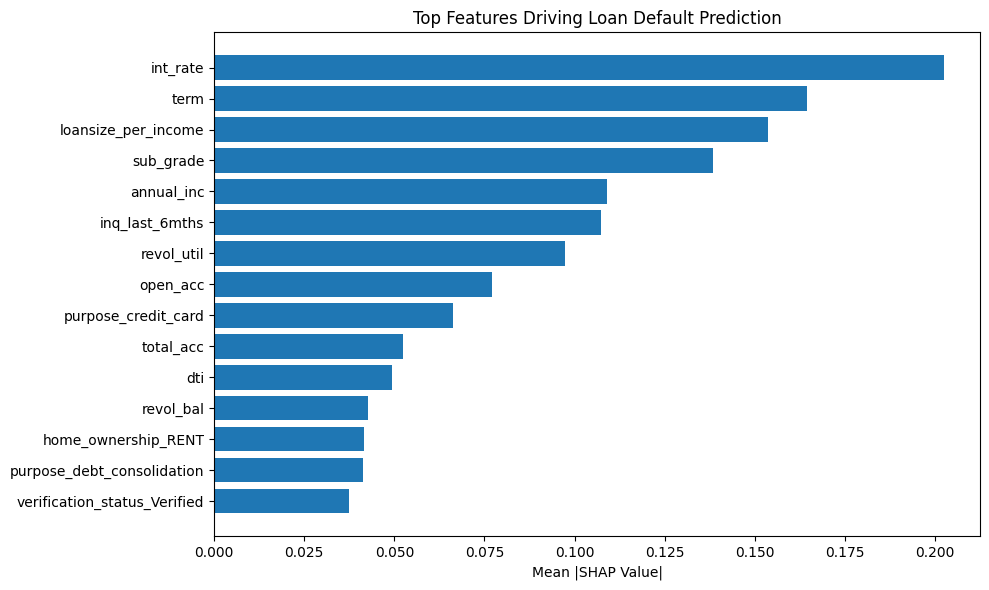

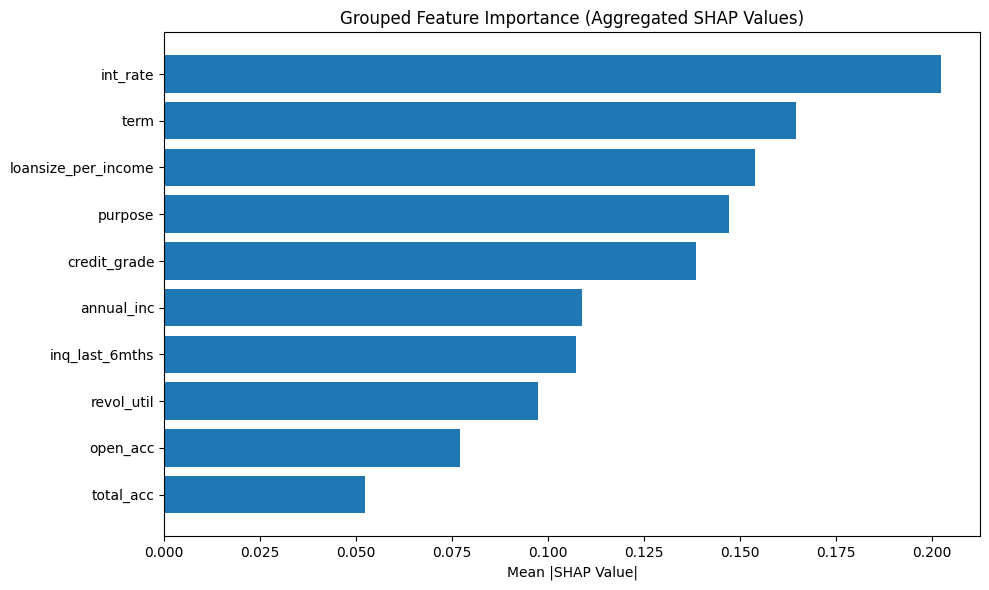

In [69]:
# Extract trained logistic regression model from pipeline
model = final_pipeline.named_steps["model"]

# SHAP works directly with linear models using LinearExplainer
explainer = shap.LinearExplainer(model, X_train, feature_perturbation="interventional")

# Compute SHAP values (test set recommended for reporting)
shap_values = explainer.shap_values(X_test)

plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Summary Plot – Logistic Regression (Undersampled Model)")
plt.savefig("shap_summary_plot_logistic.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("Global Feature Importance (Mean |SHAP| Values)")
plt.savefig("shap_feature_importance_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# Compute mean absolute SHAP values
shap_abs_mean = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": shap_abs_mean
}).sort_values("mean_abs_shap", ascending=False)

shap_df.to_csv("shap_feature_importance.csv", index=False)

top_n = 15
top_features = shap_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["mean_abs_shap"])
plt.xlabel("Mean |SHAP Value|")
plt.title("Top Features Driving Loan Default Prediction")
plt.tight_layout()

plt.savefig("shap_top_features.png", dpi=300, bbox_inches="tight")
plt.show()

# Create dataframe of SHAP values
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)

# Map encoded features back to original groups
def group_feature(name):
    if "purpose" in name:
        return "purpose"
    elif "grade" in name:
        return "credit_grade"
    elif "home" in name or "ownership" in name:
        return "home_ownership"
    else:
        return name  # keep numerical features as-is

grouped = {}

for col in shap_df.columns:
    group = group_feature(col)
    grouped.setdefault(group, []).append(col)

# Aggregate absolute SHAP values by group
group_importance = {
    group: np.abs(shap_df[cols]).mean().sum()
    for group, cols in grouped.items()
}

group_importance_df = pd.DataFrame(
    list(group_importance.items()),
    columns=["feature_group", "mean_abs_shap"]
).sort_values("mean_abs_shap", ascending=False)

group_importance_df.to_csv("shap_grouped_importance.csv", index=False)

top_n = 10
plot_df = group_importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature_group"], plot_df["mean_abs_shap"])
plt.xlabel("Mean |SHAP Value|")
plt.title("Grouped Feature Importance (Aggregated SHAP Values)")
plt.tight_layout()

plt.savefig("shap_grouped_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [70]:
# Get probabilities and predictions
probs = final_pipeline.predict_proba(X_test)[:, 1]
preds = (probs >= best_threshold).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

# Metrics
default_capture = tp / (tp + fn)          # recall
false_positive_rate = fp / (fp + tn)
precision = tp / (tp + fp)
base_rate = y_test.mean()

# Print results
print("Default Capture Rate (Recall):", default_capture)
print("False Positive Rate:", false_positive_rate)
print("Precision (Risk Concentration):", precision)
print("Base Default Rate:", base_rate)
print("Lift in Precision:", precision / base_rate)

Default Capture Rate (Recall): 0.6307901907356949
False Positive Rate: 0.3480395241991315
Precision (Risk Concentration): 0.2508805201842319
Base Default Rate: 0.15596281540504647
Lift in Precision: 1.6085918911676313


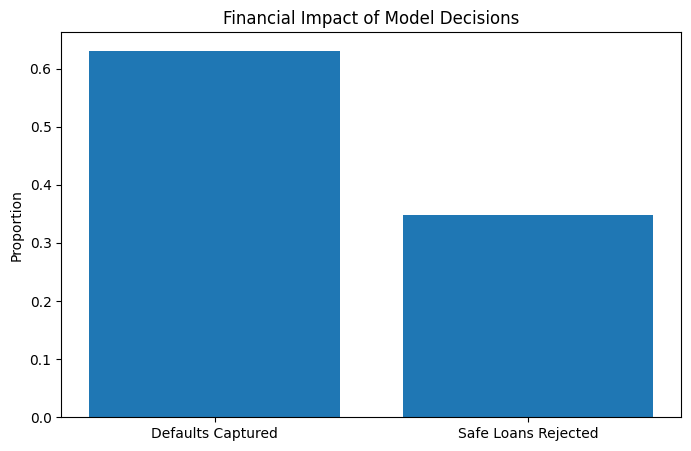

In [71]:
labels = ["Defaults Captured", "Safe Loans Rejected"]
values = [default_capture, false_positive_rate]

plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.ylabel("Proportion")
plt.title("Financial Impact of Model Decisions")

plt.savefig("financial_impact_bar.png", dpi=300, bbox_inches="tight")
plt.show()

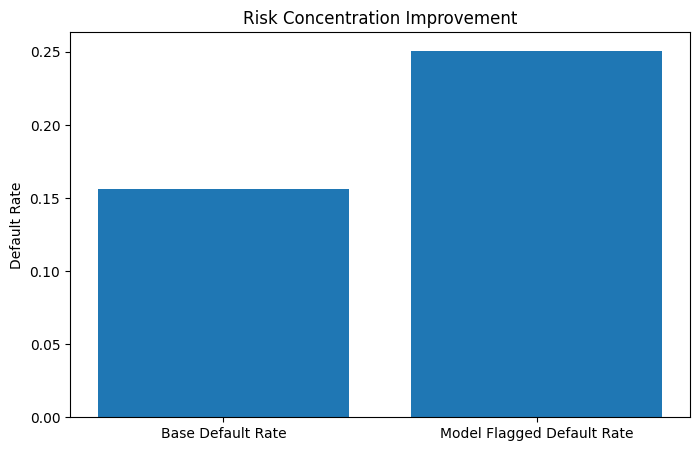

In [72]:
labels = ["Base Default Rate", "Model Flagged Default Rate"]
values = [base_rate, precision]

plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.ylabel("Default Rate")
plt.title("Risk Concentration Improvement")

plt.savefig("risk_concentration.png", dpi=300, bbox_inches="tight")
plt.show()

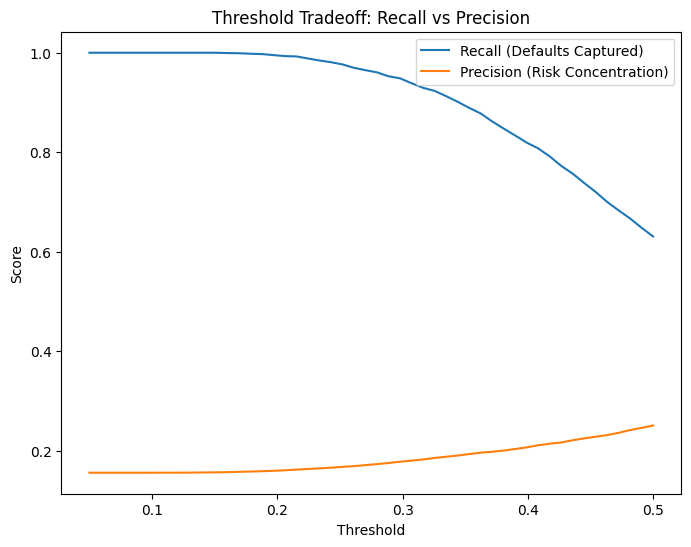

In [73]:
thresholds = np.linspace(0.05, 0.5, 50)

recalls = []
precisions = []

for t in thresholds:
    preds_t = (probs >= t).astype(int)
    recalls.append(recall_score(y_test, preds_t))
    precisions.append(precision_score(y_test, preds_t))

plt.figure(figsize=(8,6))
plt.plot(thresholds, recalls, label="Recall (Defaults Captured)")
plt.plot(thresholds, precisions, label="Precision (Risk Concentration)")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tradeoff: Recall vs Precision")
plt.legend()

plt.savefig("threshold_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

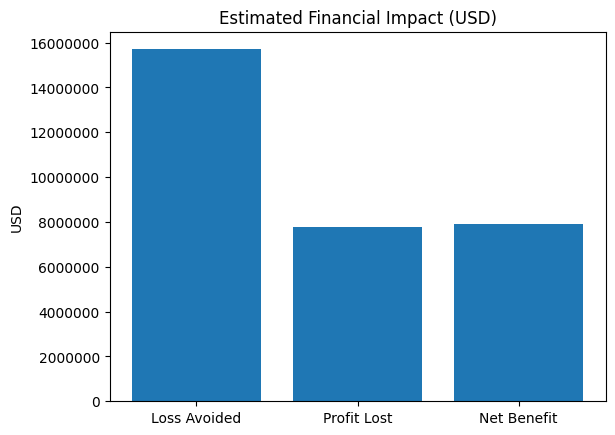

In [74]:
L= np.mean(baseline_df["loan_amnt"])
LGD = .6 #Lending Club specifically often reported ~60–70%
r=.1 #profit on paid loans
loss_avoided = 1886 * L* LGD
profit_lost = 5612 * L* r
net = loss_avoided - profit_lost

labels = ["Loss Avoided", "Profit Lost", "Net Benefit"]
values = [loss_avoided, profit_lost, net]

plt.figure()
plt.bar(labels, values)

plt.ylabel("USD")

# readable scale (millions)
plt.ticklabel_format(style='plain', axis='y')

plt.title("Estimated Financial Impact (USD)")

plt.savefig("financial_impact_dollars.png", dpi=300, bbox_inches="tight")
plt.show()

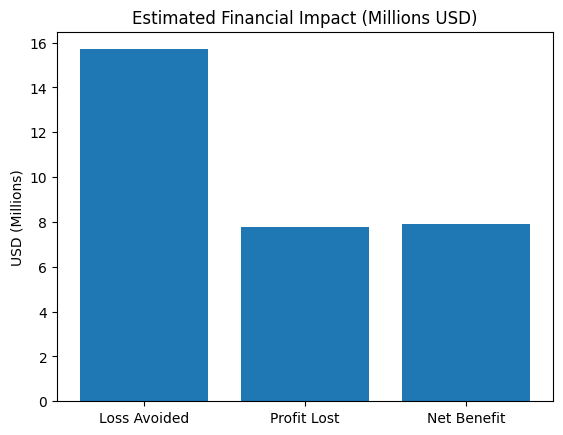

In [75]:
values_millions = [v / 1e6 for v in values]

plt.figure()
plt.bar(labels, values_millions)
plt.ylabel("USD (Millions)")
plt.title("Estimated Financial Impact (Millions USD)")

plt.savefig("financial_impact_millions.png", dpi=300, bbox_inches="tight")
plt.show()

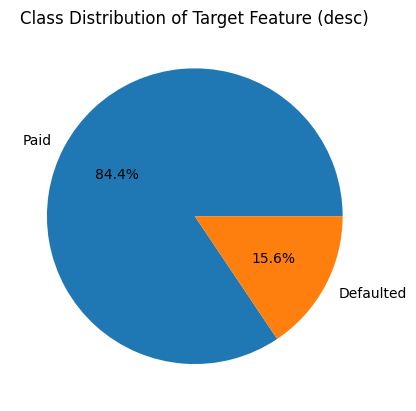

In [76]:
# Count class distribution
class_counts = y.value_counts() 

# Create pie chart
plt.figure()
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%')
plt.title("Class Distribution of Target Feature (desc)")
plt.savefig("class_distribution_pie.png", bbox_inches='tight', dpi=300)
plt.show()

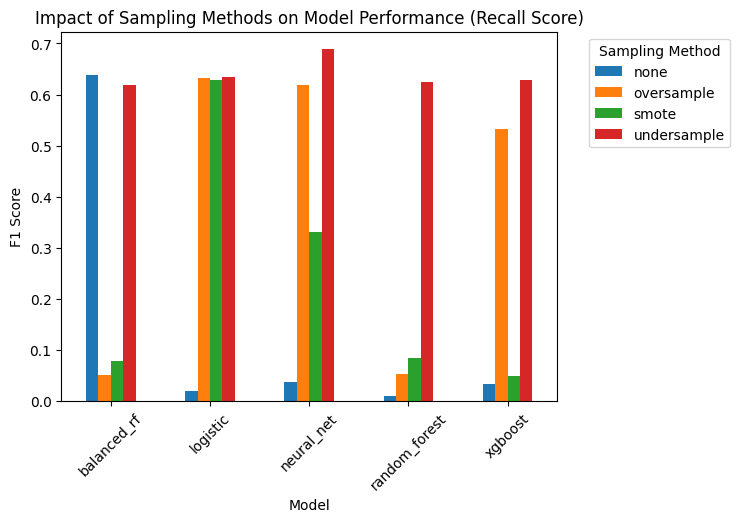

In [79]:
balance = pd.read_csv("C:/Users/Krafc/Downloads/MSBA Capstone/resampled_models_results.csv")
balance
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv("C:/Users/Krafc/Downloads/MSBA Capstone/resampled_models_results.csv")


# Split model and sampling into separate columns
df[['model_name', 'sampling']] = df['Model'].str.extract(r'(\w+)\s*\((.*?)\)')

# Pivot for grouped bar chart
pivot_df = df.pivot(index='model_name', columns='sampling', values='Recall')

# Plot
pivot_df.plot(kind='bar')

plt.title("Impact of Sampling Methods on Model Performance (Recall Score)")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.legend(title="Sampling Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig("sampling_impact_recall.png", dpi=300, bbox_inches='tight')
plt.show()

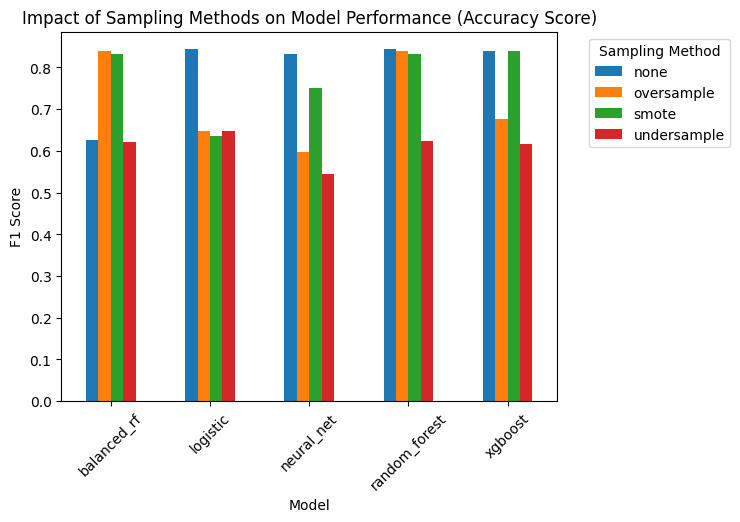

In [80]:
df = pd.read_csv("C:/Users/Krafc/Downloads/MSBA Capstone/resampled_models_results.csv")

# Split model and sampling into separate columns
df[['model_name', 'sampling']] = df['Model'].str.extract(r'(\w+)\s*\((.*?)\)')

# Pivot for grouped bar chart
pivot_df = df.pivot(index='model_name', columns='sampling', values='Accuracy')

# Plot
pivot_df.plot(kind='bar')

plt.title("Impact of Sampling Methods on Model Performance (Accuracy Score)")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.legend(title="Sampling Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig("sampling_impact_accuracy.png", dpi=300, bbox_inches='tight')
plt.show()

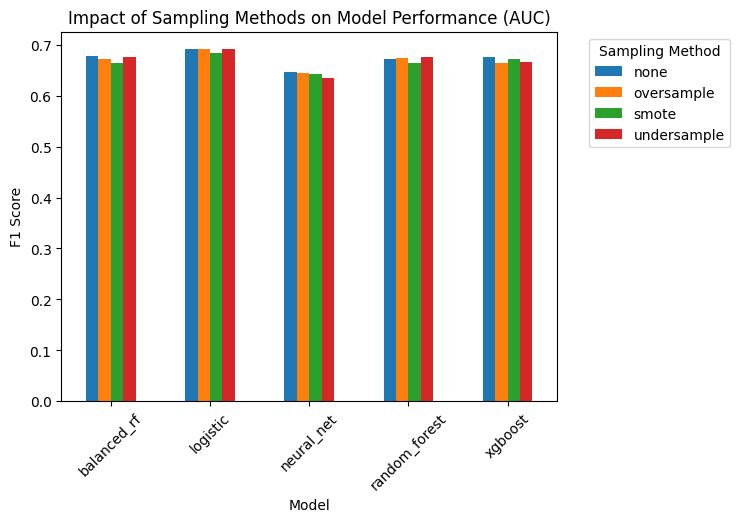

In [81]:
df = pd.read_csv("C:/Users/Krafc/Downloads/MSBA Capstone/resampled_models_results.csv")

# Split model and sampling into separate columns
df[['model_name', 'sampling']] = df['Model'].str.extract(r'(\w+)\s*\((.*?)\)')

# Pivot for grouped bar chart
pivot_df = df.pivot(index='model_name', columns='sampling', values='AUC')

# Plot
pivot_df.plot(kind='bar')

plt.title("Impact of Sampling Methods on Model Performance (AUC)")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.legend(title="Sampling Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig("sampling_impact_AUC.png", dpi=300, bbox_inches='tight')
plt.show()

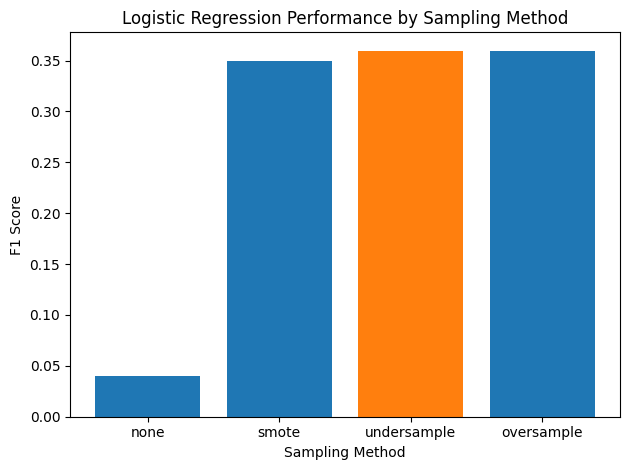

In [82]:
df = pd.read_csv("C:/Users/Krafc/Downloads/MSBA Capstone/resampled_models_results.csv")

# Extract model + sampling
df[['model_name', 'sampling']] = df['Model'].str.extract(r'(\w+)\s*\((.*?)\)')

# Filter for logistic regression only
log_df = df[df['model_name'] == 'logistic']

# Sort for consistent order
order = ['none', 'smote', 'undersample', 'oversample']
log_df['sampling'] = pd.Categorical(log_df['sampling'], categories=order, ordered=True)
log_df = log_df.sort_values('sampling')

# Plot F1 
plt.figure()
plt.bar(log_df['sampling'], log_df['F1'])

plt.title("Logistic Regression Performance by Sampling Method")
plt.xlabel("Sampling Method")
plt.ylabel("F1 Score")

# Highlight undersampling bar
for i, val in enumerate(log_df['sampling']):
    if val == 'undersample':
        plt.bar(i, log_df.iloc[i]['F1'])  # redraw 

plt.tight_layout()
plt.savefig("logistic_sampling_focus.png", dpi=300, bbox_inches='tight')
plt.show()